# Chapter 20: Tone Reproduction

Source span: *Fundamentals of Computer Graphics*, Chapter 20, printed pages 569-594, physical PDF pages 586-611.

Chapter goal: turn high dynamic range radiance-like image data into displayable low dynamic range images while preserving the signal that matters for a task: visible detail, local contrast, plausible brightness, and stable color appearance.

The chapter is not just a gallery of tone curves. It is about choosing what information is allowed to move when a scene has more luminance range than the display. A tone reproduction operator compresses luminance; the design question is whether it should preserve ratios, gradients, local contrast, color ratios, or an appearance cue such as night vision.

In [ ]:
# geometry-setup:v1
# Machine-managed by scripts/update_notebook_setup.py. Do not edit this cell by hand.

from __future__ import annotations

import json as _geometry_json
import os as _geometry_os
from pathlib import Path as _GeometryPath
import sys as _geometry_sys

GEOMETRY_SETUP = _geometry_json.loads(
    r"""
{
  "colab_url": "https://colab.research.google.com/github/Rah-Rah-Mitra/Geometry/blob/main/Fundamentals-of-Computer-Graphics/chapter-20-tone-reproduction/20-tone-reproduction.ipynb",
  "course_dir": "Fundamentals-of-Computer-Graphics",
  "course_title": "Fundamentals of Computer Graphics",
  "github_url": "https://github.com/Rah-Rah-Mitra/Geometry/blob/main/Fundamentals-of-Computer-Graphics/chapter-20-tone-reproduction/20-tone-reproduction.ipynb",
  "jupyterlite": false,
  "marker": "geometry-setup:v1",
  "notebook_kind": "lesson",
  "notebook_path": "Fundamentals-of-Computer-Graphics/chapter-20-tone-reproduction/20-tone-reproduction.ipynb",
  "notebook_title": "Chapter 20: Tone Reproduction",
  "repository": {
    "branch": "main",
    "name": "Geometry",
    "owner": "Rah-Rah-Mitra",
    "source_url": "https://github.com/Rah-Rah-Mitra/Geometry"
  },
  "requirements": "requirements/graphics.txt",
  "runtime_profile": "graphics"
}
"""
)


def _geometry_is_colab():
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return False


def _geometry_is_jupyterlite():
    return _geometry_sys.platform == "emscripten" or "pyodide" in _geometry_sys.modules


def _geometry_add_path(path):
    text = str(path)
    if text not in _geometry_sys.path:
        _geometry_sys.path.insert(0, text)


def _geometry_find_repo_root():
    candidates = []
    env_root = _geometry_os.environ.get("GEOMETRY_REPO_ROOT")
    if env_root:
        candidates.append(_GeometryPath(env_root).expanduser())
    candidates.append(_GeometryPath.cwd())
    for start in candidates:
        start = start.resolve()
        for current in (start, *start.parents):
            if (current / "course-manifest.json").exists() and (
                current / "metadata" / "runtime_profiles.yml"
            ).exists():
                return current
    raise RuntimeError(
        "Could not find the Geometry repository root. Start JupyterLab inside the "
        "Geometry checkout or set GEOMETRY_REPO_ROOT."
    )


def _geometry_run(command):
    import subprocess as _geometry_subprocess

    printable = " ".join(str(part) for part in command)
    print(f"+ {printable}")
    _geometry_subprocess.check_call([str(part) for part in command])


def _geometry_requirement_names(requirements_path, seen=None):
    seen = set() if seen is None else seen
    requirements_path = requirements_path.resolve()
    if requirements_path in seen or not requirements_path.exists():
        return []
    seen.add(requirements_path)
    names = []
    for raw_line in requirements_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.split("#", 1)[0].strip()
        if not line:
            continue
        if line.startswith(("-r ", "--requirement ")):
            _, nested = line.split(maxsplit=1)
            names.extend(_geometry_requirement_names(requirements_path.parent / nested, seen))
            continue
        if line.startswith("-"):
            continue
        name = line
        for separator in ("==", ">=", "<=", "~=", "!=", ">", "<", ";"):
            name = name.split(separator, 1)[0]
        name = name.split("[", 1)[0].strip()
        if name:
            names.append(name)
    return sorted(set(names))


def _geometry_missing_requirements(requirements_path):
    import importlib.metadata as _geometry_metadata

    missing = []
    for name in _geometry_requirement_names(requirements_path):
        try:
            _geometry_metadata.distribution(name)
        except _geometry_metadata.PackageNotFoundError:
            missing.append(name)
    return missing


def _geometry_configured_roots(repo_root):
    course_dir = GEOMETRY_SETUP.get("course_dir")
    course_root = repo_root / course_dir if course_dir else repo_root
    return repo_root, course_root


if _geometry_is_jupyterlite():
    if not GEOMETRY_SETUP["jupyterlite"]:
        raise RuntimeError(
            "This Geometry notebook uses runtime profile "
            f"{GEOMETRY_SETUP['runtime_profile']!r}, which is not enabled for "
            "JupyterLite in course-manifest.json. Open it in Colab or local JupyterLab."
        )
    GEOMETRY_REPO_ROOT = _GeometryPath.cwd()
    GEOMETRY_COURSE_ROOT = (
        GEOMETRY_REPO_ROOT / GEOMETRY_SETUP["course_dir"]
        if GEOMETRY_SETUP.get("course_dir")
        else GEOMETRY_REPO_ROOT
    )
    _geometry_add_path(GEOMETRY_REPO_ROOT)
    if GEOMETRY_COURSE_ROOT.exists():
        _geometry_add_path(GEOMETRY_COURSE_ROOT)
    GEOMETRY_RUNTIME_PROFILE = GEOMETRY_SETUP["runtime_profile"]
    print(
        "Geometry setup: JupyterLite/Pyodide detected; shell, git, and pip steps "
        "were skipped."
    )
elif _geometry_is_colab():
    repository = GEOMETRY_SETUP["repository"]
    repo_url = repository["source_url"].rstrip("/") + ".git"
    branch = repository["branch"]
    GEOMETRY_REPO_ROOT = _GeometryPath(
        _geometry_os.environ.get("GEOMETRY_REPO_ROOT", "/content/Geometry")
    )
    sparse_paths = ["requirements", "metadata", "scripts", "course-manifest.json", "index.ipynb"]
    if GEOMETRY_SETUP.get("course_dir"):
        sparse_paths.append(GEOMETRY_SETUP["course_dir"])
    if not (GEOMETRY_REPO_ROOT / ".git").exists():
        if GEOMETRY_REPO_ROOT.exists() and any(GEOMETRY_REPO_ROOT.iterdir()):
            raise RuntimeError(
                f"{GEOMETRY_REPO_ROOT} exists but is not a git checkout. "
                "Set GEOMETRY_REPO_ROOT to an empty path or remove the directory."
            )
        _geometry_run(
            [
                "git",
                "clone",
                "--filter=blob:none",
                "--no-checkout",
                "--branch",
                branch,
                repo_url,
                GEOMETRY_REPO_ROOT,
            ]
        )
        _geometry_run(["git", "-C", GEOMETRY_REPO_ROOT, "sparse-checkout", "init", "--cone"])
    _geometry_run(["git", "-C", GEOMETRY_REPO_ROOT, "sparse-checkout", "set", *sparse_paths])
    _geometry_run(["git", "-C", GEOMETRY_REPO_ROOT, "checkout", branch])
    requirements_path = GEOMETRY_REPO_ROOT / GEOMETRY_SETUP["requirements"]
    _geometry_run([_geometry_sys.executable, "-m", "pip", "install", "-q", "-r", requirements_path])
    GEOMETRY_REPO_ROOT, GEOMETRY_COURSE_ROOT = _geometry_configured_roots(GEOMETRY_REPO_ROOT)
    _geometry_os.chdir(GEOMETRY_COURSE_ROOT if GEOMETRY_COURSE_ROOT.exists() else GEOMETRY_REPO_ROOT)
    _geometry_add_path(GEOMETRY_REPO_ROOT)
    _geometry_add_path(GEOMETRY_COURSE_ROOT)
    GEOMETRY_RUNTIME_PROFILE = GEOMETRY_SETUP["runtime_profile"]
    print(
        f"Geometry setup: Colab ready at {_GeometryPath.cwd()} "
        f"with profile {GEOMETRY_RUNTIME_PROFILE!r}."
    )
else:
    GEOMETRY_REPO_ROOT = _geometry_find_repo_root()
    requirements_path = GEOMETRY_REPO_ROOT / GEOMETRY_SETUP["requirements"]
    missing = _geometry_missing_requirements(requirements_path)
    skip_install = _geometry_os.environ.get("GEOMETRY_SKIP_INSTALL") == "1"
    if missing and skip_install:
        print(
            "Geometry setup: GEOMETRY_SKIP_INSTALL=1, so missing profile packages "
            f"were not installed: {', '.join(missing)}"
        )
    elif missing:
        print(
            "Geometry setup: installing missing profile packages from "
            f"{requirements_path.relative_to(GEOMETRY_REPO_ROOT)}: {', '.join(missing)}"
        )
        _geometry_run([_geometry_sys.executable, "-m", "pip", "install", "-r", requirements_path])
    GEOMETRY_REPO_ROOT, GEOMETRY_COURSE_ROOT = _geometry_configured_roots(GEOMETRY_REPO_ROOT)
    _geometry_os.chdir(GEOMETRY_COURSE_ROOT if GEOMETRY_COURSE_ROOT.exists() else GEOMETRY_REPO_ROOT)
    _geometry_add_path(GEOMETRY_REPO_ROOT)
    _geometry_add_path(GEOMETRY_COURSE_ROOT)
    GEOMETRY_RUNTIME_PROFILE = GEOMETRY_SETUP["runtime_profile"]
    print(
        f"Geometry setup: local checkout ready at {_GeometryPath.cwd()} "
        f"with profile {GEOMETRY_RUNTIME_PROFILE!r}."
    )


## Translation guide: computational version

| Source idea | Computational object in this notebook | What to inspect | Check used here |
| --- | --- | --- | --- |
| HDR scene and LDR display | Floating point RGB arrays mapped to `[0, 1]` display arrays | Where linear scaling loses dark detail or clips bright detail | Percentile dynamic range and clipping fraction |
| Dynamic range | `log10(P99.9 / P0.1)` and stops `log2(P99.9 / P0.1)` | The same range can be shifted darker without becoming lower range | Robust range ignores isolated outliers |
| Image formation | Synthetic `luminance = reflectance * illuminance + highlights` | Log luminance turns products into sums | Reflectance stays low range while illuminance carries most range |
| Frequency operators | Log-luminance base/detail split with low-frequency attenuation | Low frequencies hold illumination; details survive recombination | Output range is smaller than input range |
| Gradient operators | Compressed log-gradient field integrated by a Poisson solve | Sharp highlight gradients are attenuated before reconstruction | Reconstructed gradients match the compressed field within a tolerance |
| Spatial operators | Global and local sigmoid/division operators | Local adaptation helps shadows but can create halos | Halo score near a synthetic step edge |
| Color preservation | Luminance remapping plus RGB/luminance ratios | `s=1` preserves channel ratios before clipping; lower `s` desaturates | Chromaticity drift ledger |
| Night tone mapping | Scotopic channel, blue-gray shift, contrast loss, acuity loss | Night appearance is not just making the image darker | Luminance, saturation, and detail metrics all drop |

Library routing: `numpy` and `scipy` carry the HDR arrays, filters, FFTs, gradients, and Poisson solve; `scikit-image` supplies bilateral filtering for edge-preserving local adaptation; `matplotlib` creates durable PNG teaching artifacts; `plotly` creates the tone-curve parameter lab as standalone HTML; course-local artifact helpers save, display, and validate outputs.

## Visual storyboard

| Order | Artifact | Concept | Representation and library | Learner inspection target | Validation |
| --- | --- | --- | --- | --- | --- |
| 1 | `hdr-ldr-range-ladder.png` | HDR scene range vs LDR display range | Matplotlib histogram and range ladder | Why a byte display cannot hold the scene range linearly | Robust log range and stop count |
| 2 | `tone-curve-family.html`, `tone-curve-family-static.png` | Linear, clamp, log, Reinhard, sigmoid mappings | Plotly HTML plus static Matplotlib fallback | How semi-saturation and asymptotes move detail | Sigmoid maps `L=f` to 0.5 when `n=1` |
| 3 | `synthetic-hdr-exposure-compression.png` | Exposure choice, clipping, and compression | Synthetic HDR image grid | Indoor/outdoor tradeoff and recovered detail | Clipped-pixel fractions |
| 4 | `image-formation-log-base-detail.png` | Reflectance, illuminance, base/detail split | Log-luminance panels | Multiplicative image formation becomes additive in density | Reflectance dynamic range is lower than illuminance range |
| 5 | `frequency-gradient-operator-comparison.png` | Frequency and gradient-domain operators | FFT base compression, gradient compression, Poisson reconstruction | Which structures survive each domain transform | Poisson residual and range compression |
| 6 | `spatial-local-adaptation-halos.png` | Local adaptation and halo tradeoff | Division, local sigmoid, bilateral local average | Why blurring across a contrast edge creates bands | Halo score near the edge |
| 7 | `color-preservation-saturation.png` | Luminance mapping, saturation, chromatic adaptation | Ratio-preserving and per-channel maps | How preserving ratios differs from adapting colorfulness | Chromaticity error and ratio preservation |
| 8 | `scotopic-night-operator.png` | Night tone reproduction | XYZ/scotopic channel, blue shift, bilateral acuity loss | Why night mapping changes acuity and color, not only brightness | Mean luminance, saturation, and detail reduction |
| 9 | `tone-reproduction-check-ledger.csv`, `tone-reproduction-invariants.json` | Operator comparison | Tables and JSON | Which operator preserves which signal | Final assertions |

In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import ndimage
from scipy.fft import fft2, ifft2, fftfreq
from skimage.restoration import denoise_bilateral

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the Fundamentals of Computer Graphics course root.")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    ARTIFACT_ROOT,
    assert_artifacts,
    book_relative,
    display_artifact,
    save_image,
    save_json,
    save_matplotlib,
    save_plotly_html,
    save_table_csv,
)
from utils.notebook_checks import assert_nonblank_image

CHAPTER = 20
TOPIC = "chapter-20"
TITLE = "Tone Reproduction"
PRINTED_PAGES = "569-594"
PDF_PAGES = "586-611"
SOURCE_SPAN = f"printed pages {PRINTED_PAGES}; physical PDF pages {PDF_PAGES}"

rng = np.random.default_rng(20)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 170,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})

fig_dir = ARTIFACT_ROOT / TOPIC / "figures"
html_dir = ARTIFACT_ROOT / TOPIC / "html"
checks_dir = ARTIFACT_ROOT / TOPIC / "checks"
tables_dir = ARTIFACT_ROOT / TOPIC / "tables"
for directory in [fig_dir, html_dir, checks_dir, tables_dir]:
    directory.mkdir(parents=True, exist_ok=True)

generated_artifacts = []
image_artifacts = []
operator_outputs = {}
metrics_rows = []

def remember(path, kind="artifact"):
    path = Path(path)
    generated_artifacts.append(path)
    if kind == "image":
        image_artifacts.append(path)
    return path

def luminance(rgb):
    rgb = np.asarray(rgb, dtype=float)
    return 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]

def robust_range(values, low=0.001, high=0.999, eps=1e-9):
    values = np.asarray(values, dtype=float)
    positive = values[np.isfinite(values) & (values > eps)]
    lo, hi = np.quantile(positive, [low, high])
    return {
        "p_low": float(lo),
        "p_high": float(hi),
        "ratio": float(hi / max(lo, eps)),
        "log10": float(np.log10(hi / max(lo, eps))),
        "stops": float(np.log2(hi / max(lo, eps))),
    }

def geometric_mean(values, eps=1e-6):
    values = np.asarray(values, dtype=float)
    return float(np.exp(np.mean(np.log(np.maximum(values, eps)))))

def normalize01(values, low=0.001, high=0.999):
    values = np.asarray(values, dtype=float)
    lo, hi = np.quantile(values[np.isfinite(values)], [low, high])
    if hi <= lo:
        return np.zeros_like(values, dtype=float)
    return np.clip((values - lo) / (hi - lo), 0.0, 1.0)

def display_from_luminance(rgb, Ld, s=1.0, clip=True):
    L = luminance(rgb)
    ratio = np.divide(rgb, L[..., None] + 1e-9)
    out = (np.maximum(ratio, 0.0) ** s) * Ld[..., None]
    return np.clip(out, 0.0, 1.0) if clip else out

def reinhard_global_luminance(L, key=0.18):
    Lbar = geometric_mean(L)
    scaled = (key / max(Lbar, 1e-9)) * L
    return scaled / (1.0 + scaled)

def sigmoid_luminance(L, f, n=1.0):
    L = np.asarray(L, dtype=float)
    f = np.asarray(f, dtype=float)
    return np.power(L, n) / (np.power(L, n) + np.power(np.maximum(f, 1e-9), n))

def log_luminance_map(L):
    Lmax = float(np.max(L))
    return np.log1p(L) / np.log1p(Lmax)

def local_contrast_score(image_rgb):
    L = luminance(image_rgb)
    gy, gx = np.gradient(L)
    return float(np.mean(np.hypot(gx, gy)))

def chromaticity(rgb):
    denom = np.sum(rgb, axis=-1, keepdims=True)
    return np.divide(rgb, denom + 1e-9)

def add_operator_metric(name, rgb, reference_rgb=None, clipped_source=None, notes=""):
    L = luminance(rgb)
    rr = robust_range(np.maximum(L, 1e-9))
    if clipped_source is None:
        clipped_source = rgb
    clipped_fraction = float(np.mean((clipped_source <= 0.0) | (clipped_source >= 1.0)))
    row = {
        "operator": name,
        "display_min": float(np.min(rgb)),
        "display_max": float(np.max(rgb)),
        "luminance_log10_range": rr["log10"],
        "luminance_stops": rr["stops"],
        "clipped_fraction": clipped_fraction,
        "mean_gradient": local_contrast_score(rgb),
        "notes": notes,
    }
    if reference_rgb is not None:
        row["mean_chromaticity_error"] = float(np.mean(np.linalg.norm(chromaticity(rgb) - chromaticity(reference_rgb), axis=-1)))
    metrics_rows.append(row)
    operator_outputs[name] = rgb
    return row

## 1. Build a synthetic HDR scene

The source chapter repeatedly uses indoor/outdoor scenes, highlights, and bright light sources to motivate tone reproduction. To avoid copied images and to keep every value inspectable, this notebook uses a synthetic scene with the same numerical problem: a dim interior, a bright window, texture-like reflectance, colored surfaces, and specular highlights.

The synthetic construction gives us two known components. Reflectance is deliberately low range: it is a surface property. Illuminance varies over many orders of magnitude: it is the main reason the final image is HDR. Specular highlights and visible light sources violate the purely diffuse assumption, which is exactly where simple base/detail interpretations become imperfect but still useful.

In [2]:
H, W = 190, 300
y = np.linspace(0.0, 1.0, H)
x = np.linspace(0.0, 1.0, W)
X, Y = np.meshgrid(x, y)

window = (X > 0.58) & (X < 0.96) & (Y > 0.08) & (Y < 0.58)
table = ((X - 0.34) / 0.34) ** 2 + ((Y - 0.72) / 0.18) ** 2 < 1.0
floor = Y > 0.62
left_wall = X < 0.57

illuminance = 0.035 + 0.13 * (1.0 - Y) + 0.05 * np.cos(2 * np.pi * X) ** 2
illuminance += 0.18 * floor * (Y - 0.62)
illuminance[window] = 85.0 + 340.0 * (1.0 - Y[window])
illuminance += 32.0 * np.exp(-((X - 0.20) ** 2 + (Y - 0.22) ** 2) / 0.0035)
illuminance += 5200.0 * np.exp(-((X - 0.82) ** 2 + (Y - 0.18) ** 2) / 0.0018)

reflectance = 0.22 + 0.05 * np.sin(20 * X) * np.sin(18 * Y)
reflectance += 0.18 * table
reflectance += 0.08 * ((np.floor(18 * X) + np.floor(16 * Y)) % 2) * floor
reflectance += 0.10 * left_wall * (1.0 - Y)
reflectance = np.clip(reflectance, 0.045, 0.82)

albedo = np.zeros((H, W, 3), dtype=float)
albedo[..., :] = np.array([0.58, 0.50, 0.42])
albedo[floor] = np.array([0.62, 0.52, 0.39])
albedo[table] = np.array([0.12, 0.42, 0.22])
albedo[window] = np.array([0.58, 0.72, 1.00])
albedo += 0.07 * np.stack([
    np.sin(7 * X + 1.0),
    np.sin(9 * Y + 0.4),
    np.sin(6 * X - 5 * Y),
], axis=-1)
albedo = np.clip(albedo, 0.05, 1.0)

scene_rgb = albedo * (reflectance * illuminance)[..., None]
for cx, cy, amp, color in [
    (0.32, 0.69, 140.0, np.array([1.0, 0.96, 0.80])),
    (0.43, 0.74, 95.0, np.array([0.80, 0.92, 1.0])),
    (0.22, 0.75, 60.0, np.array([1.0, 0.75, 0.62])),
]:
    spot = amp * np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / 0.0007)
    scene_rgb += spot[..., None] * color

scene_rgb *= 1.0 + rng.normal(0.0, 0.008, scene_rgb.shape)
scene_rgb = np.maximum(scene_rgb, 0.0)
scene_L = luminance(scene_rgb)
scene_range = robust_range(scene_L)
reflectance_range = robust_range(reflectance)
illuminance_range = robust_range(illuminance)

summary = pd.DataFrame([
    {"quantity": "reflectance", **reflectance_range},
    {"quantity": "illuminance", **illuminance_range},
    {"quantity": "scene luminance", **scene_range},
])
summary[["quantity", "log10", "stops", "p_low", "p_high"]]

,quantity,log10,stops,p_low,p_high
0,reflectance,0.513137,1.704605,0.170684,0.556326
1,illuminance,4.746456,15.767384,0.085147,4749.272938
2,scene luminance,5.016711,16.665153,0.007626,792.495019


The table should make the modeling assumption visible: the surface term has only a few stops of useful variation, while illuminance and highlights dominate the scene luminance range. This is why many operators work in log luminance, separate a base layer from detail, or compress a local adaptation value instead of scaling RGB channels directly.

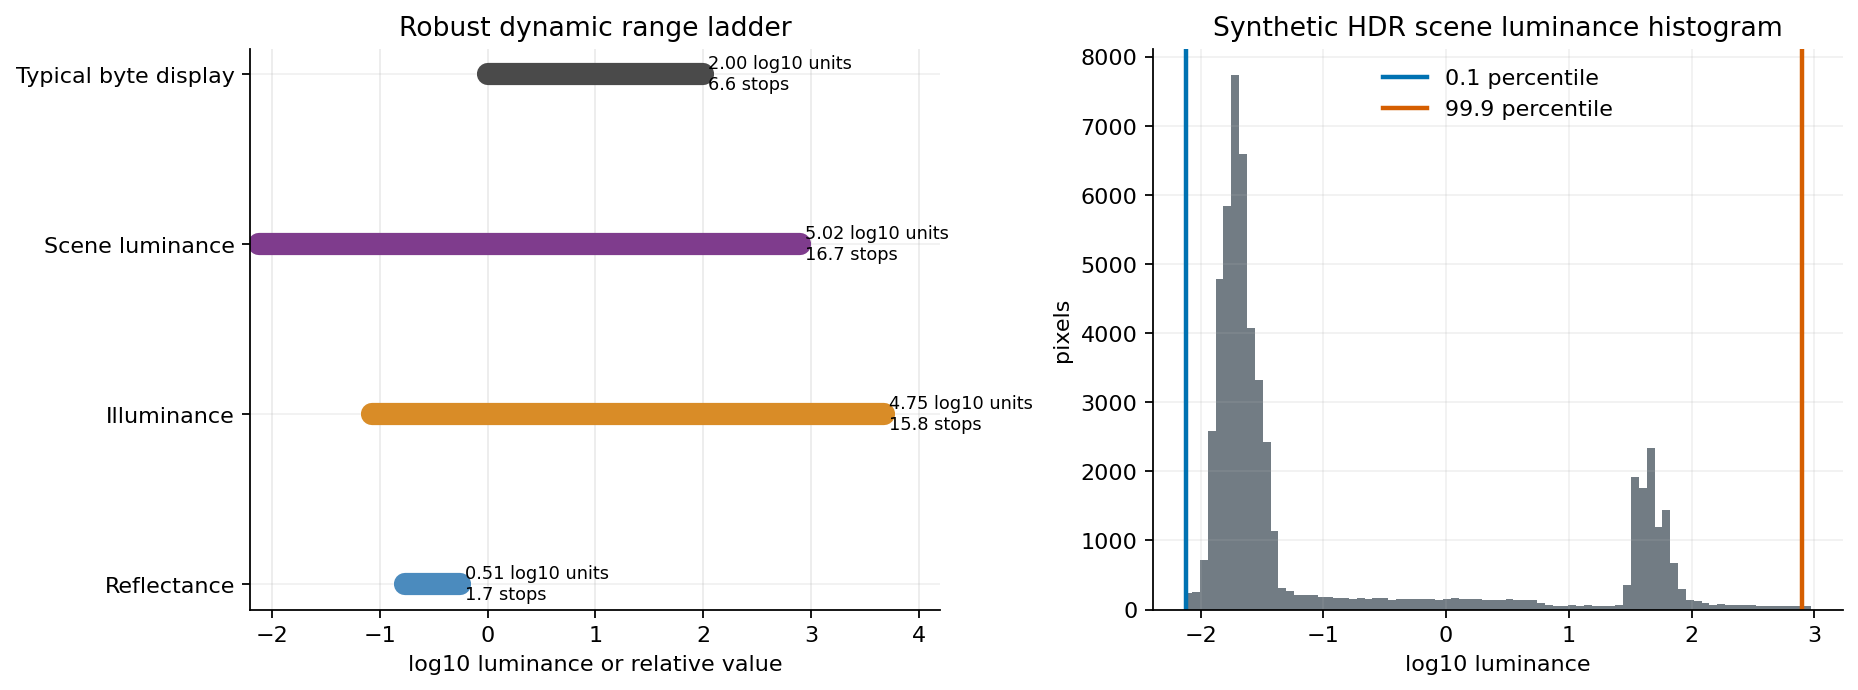

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
ax = axes[0]
quantiles = {
    "Reflectance": reflectance_range,
    "Illuminance": illuminance_range,
    "Scene luminance": scene_range,
    "Typical byte display": {"p_low": 1.0, "p_high": 100.0, "log10": 2.0, "stops": math.log2(100.0)},
}
ypos = np.arange(len(quantiles))
colors = ["#4b8bbe", "#d98c27", "#7f3c8d", "#4a4a4a"]
for i, (label, record) in enumerate(quantiles.items()):
    lo, hi = np.log10(record["p_low"]), np.log10(record["p_high"])
    ax.plot([lo, hi], [i, i], lw=10, solid_capstyle="round", color=colors[i])
    ax.text(hi + 0.05, i, f"{record['log10']:.2f} log10 units\n{record['stops']:.1f} stops", va="center", fontsize=8)
ax.set_yticks(ypos, list(quantiles.keys()))
ax.set_xlabel("log10 luminance or relative value")
ax.set_title("Robust dynamic range ladder")
ax.set_xlim(-2.2, 4.2)
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
logL = np.log10(np.maximum(scene_L, 1e-9)).ravel()
ax.hist(logL, bins=80, color="#59656f", alpha=0.85)
lo, hi = np.log10(scene_range["p_low"]), np.log10(scene_range["p_high"])
ax.axvline(lo, color="#0072b2", lw=2, label="0.1 percentile")
ax.axvline(hi, color="#d55e00", lw=2, label="99.9 percentile")
ax.set_title("Synthetic HDR scene luminance histogram")
ax.set_xlabel("log10 luminance")
ax.set_ylabel("pixels")
ax.legend(frameon=False)

range_path = remember(save_matplotlib(fig, TOPIC, "hdr-ldr-range-ladder.png"), "image")
plt.close(fig)
display_artifact(range_path, width=900)

## 2. Tone curves as transfer functions

A tone curve is a one-dimensional promise: every input luminance receives a display value. Linear scaling keeps ratios but wastes most display codes when a few highlights set the maximum. Clamping chooses an exposure and discards everything brighter than the white point. Logarithmic and sigmoid curves spend more of the display interval on dark and middle values while remaining bounded.

The semi-saturation value `f` in the sigmoid family is inspectable: when `n = 1`, an input luminance equal to `f` maps to `0.5`. The exponent `n` changes how abruptly the curve bends around that point.

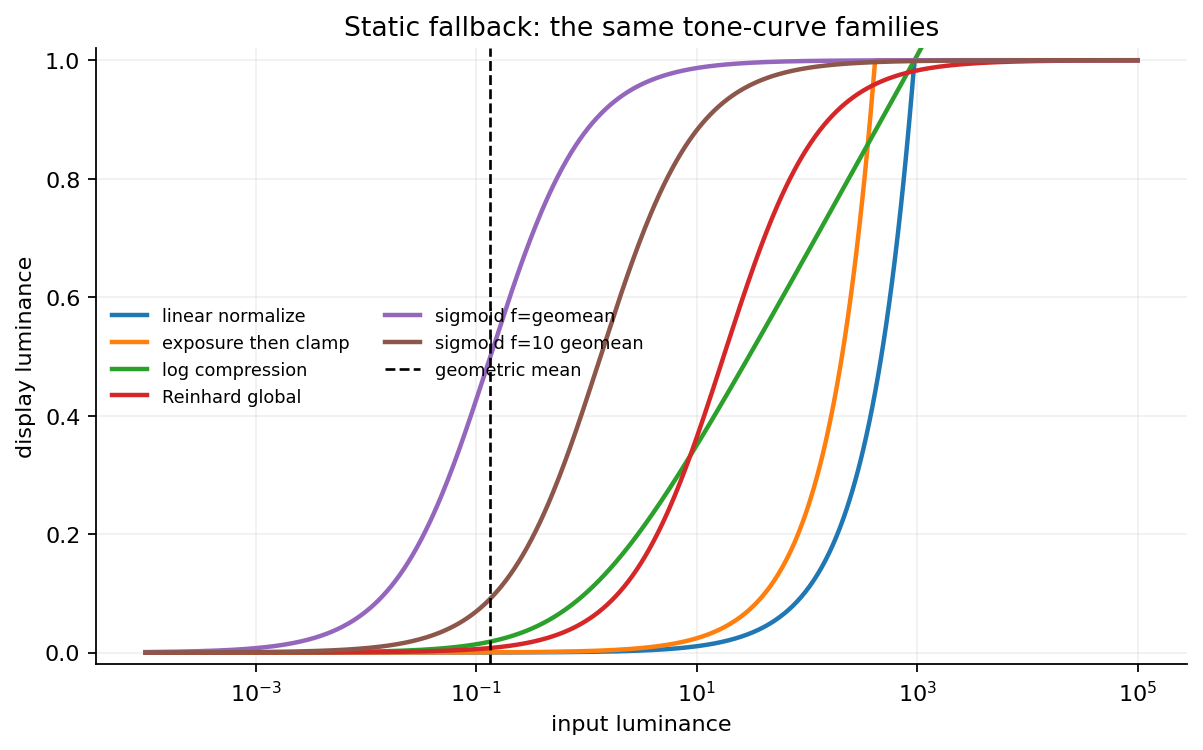

In [4]:
L_curve = np.logspace(-4, 5, 700)
white = np.quantile(scene_L, 0.995)
Lbar = geometric_mean(scene_L)
curve_data = {
    "linear normalize": np.clip(L_curve / np.max(scene_L), 0.0, 1.0),
    "exposure then clamp": np.clip(L_curve / white, 0.0, 1.0),
    "log compression": np.log1p(L_curve) / np.log1p(np.max(scene_L)),
    "Reinhard global": reinhard_global_luminance(L_curve, key=0.18),
    "sigmoid f=geomean": sigmoid_luminance(L_curve, Lbar, n=1.0),
    "sigmoid f=10 geomean": sigmoid_luminance(L_curve, 10.0 * Lbar, n=1.0),
}

plotly_fig = go.Figure()
for name, values in curve_data.items():
    plotly_fig.add_trace(go.Scatter(x=L_curve, y=values, mode="lines", name=name))
plotly_fig.update_xaxes(type="log", title="input luminance")
plotly_fig.update_yaxes(title="display luminance", range=[-0.02, 1.02])
plotly_fig.update_layout(
    title="Tone reproduction curve families",
    template="plotly_white",
    width=900,
    height=520,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
curve_html = remember(save_plotly_html(plotly_fig, TOPIC, "tone-curve-family.html"), "html")

fig, ax = plt.subplots(figsize=(8.8, 5.0))
for name, values in curve_data.items():
    ax.plot(L_curve, values, lw=2, label=name)
ax.axvline(Lbar, color="black", lw=1.2, ls="--", label="geometric mean")
ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("input luminance")
ax.set_ylabel("display luminance")
ax.set_title("Static fallback: the same tone-curve families")
ax.legend(frameon=False, fontsize=8, ncols=2)
curve_png = remember(save_matplotlib(fig, TOPIC, "tone-curve-family-static.png"), "image")
plt.close(fig)

display_artifact(curve_html, width="100%", height=540)
display_artifact(curve_png, width=820)

In [5]:
sigmoid_half_check = float(sigmoid_luminance(np.array([Lbar]), Lbar, n=1.0)[0])
assert abs(sigmoid_half_check - 0.5) < 1e-12
{"geometric_mean_luminance": Lbar, "sigmoid_at_f": sigmoid_half_check}

{'geometric_mean_luminance': 0.13431858220249934, 'sigmoid_at_f': 0.5}

## 3. Exposure, clipping, and the compression objective

The next grid uses the same HDR array under different display decisions. Exposure previews are useful because they reveal that the source data contains detail in both the room and the window. A single byte-valued image cannot show both with only multiplication and clipping. Tone reproduction is the attempt to compress the range without flattening every local difference.

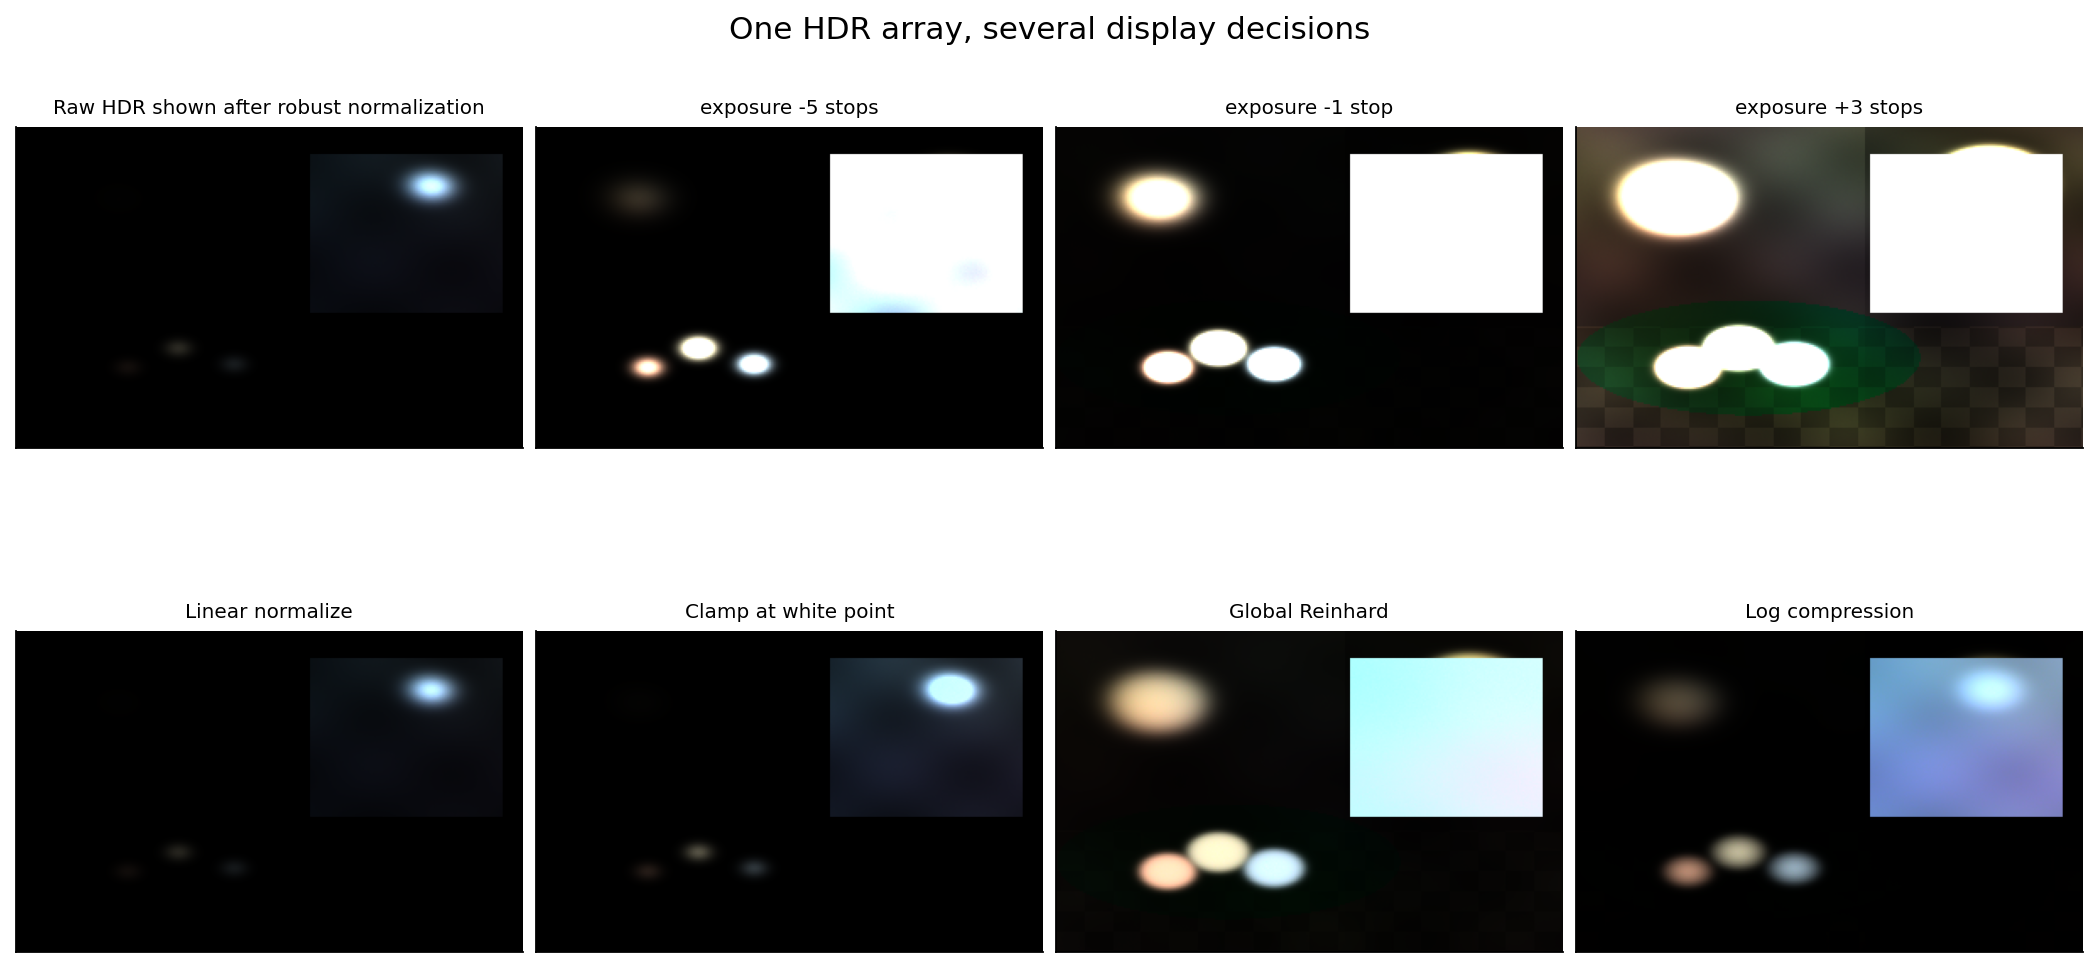

In [6]:
exposures = {
    "exposure -5 stops": np.clip(scene_rgb * 2**-5, 0.0, 1.0),
    "exposure -1 stop": np.clip(scene_rgb * 2**-1, 0.0, 1.0),
    "exposure +3 stops": np.clip(scene_rgb * 2**3, 0.0, 1.0),
}
linear_norm_L = scene_L / np.max(scene_L)
linear_norm_rgb = display_from_luminance(scene_rgb, linear_norm_L)
clamp_L = np.clip(scene_L / white, 0.0, 1.0)
clamp_rgb = display_from_luminance(scene_rgb, clamp_L)
reinhard_L = reinhard_global_luminance(scene_L, key=0.18)
reinhard_rgb = display_from_luminance(scene_rgb, reinhard_L)
log_rgb = display_from_luminance(scene_rgb, log_luminance_map(scene_L))

for name, img in exposures.items():
    add_operator_metric(name, img, reference_rgb=scene_rgb, notes="plain exposure preview")
add_operator_metric("linear normalize", linear_norm_rgb, reference_rgb=scene_rgb, clipped_source=linear_norm_L, notes="divides by global maximum")
add_operator_metric("clamp at white point", clamp_rgb, reference_rgb=scene_rgb, clipped_source=clamp_L, notes="clips highlights above selected white")
add_operator_metric("global Reinhard", reinhard_rgb, reference_rgb=scene_rgb, notes="global bounded sigmoid after key scaling")
add_operator_metric("log compression", log_rgb, reference_rgb=scene_rgb, notes="global log mapping")

fig, axes = plt.subplots(2, 4, figsize=(13, 6.3), constrained_layout=True)
panels = [
    ("Raw HDR shown after robust normalization", normalize01(scene_rgb)),
    *list(exposures.items()),
    ("Linear normalize", linear_norm_rgb),
    ("Clamp at white point", clamp_rgb),
    ("Global Reinhard", reinhard_rgb),
    ("Log compression", log_rgb),
]
for ax, (title, img) in zip(axes.ravel(), panels):
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("One HDR array, several display decisions", y=1.02, fontsize=14)
exposure_path = remember(save_matplotlib(fig, TOPIC, "synthetic-hdr-exposure-compression.png"), "image")
plt.close(fig)
display_artifact(exposure_path, width=940)

## 4. Image formation in density space

For a diffuse surface model, luminance is approximately reflectance times illuminance. Taking a logarithm turns that product into a sum. This is the reason older frequency-domain ideas and newer base/detail filters work on log luminance or density: a slowly varying base resembles illumination, while high-frequency detail resembles texture and edges.

The interpretation is exact only for ideal diffuse scenes. The synthetic highlights below intentionally break that model. The split is still computationally useful, but the base and detail layers should be treated as operator design tools, not as guaranteed physical truth.

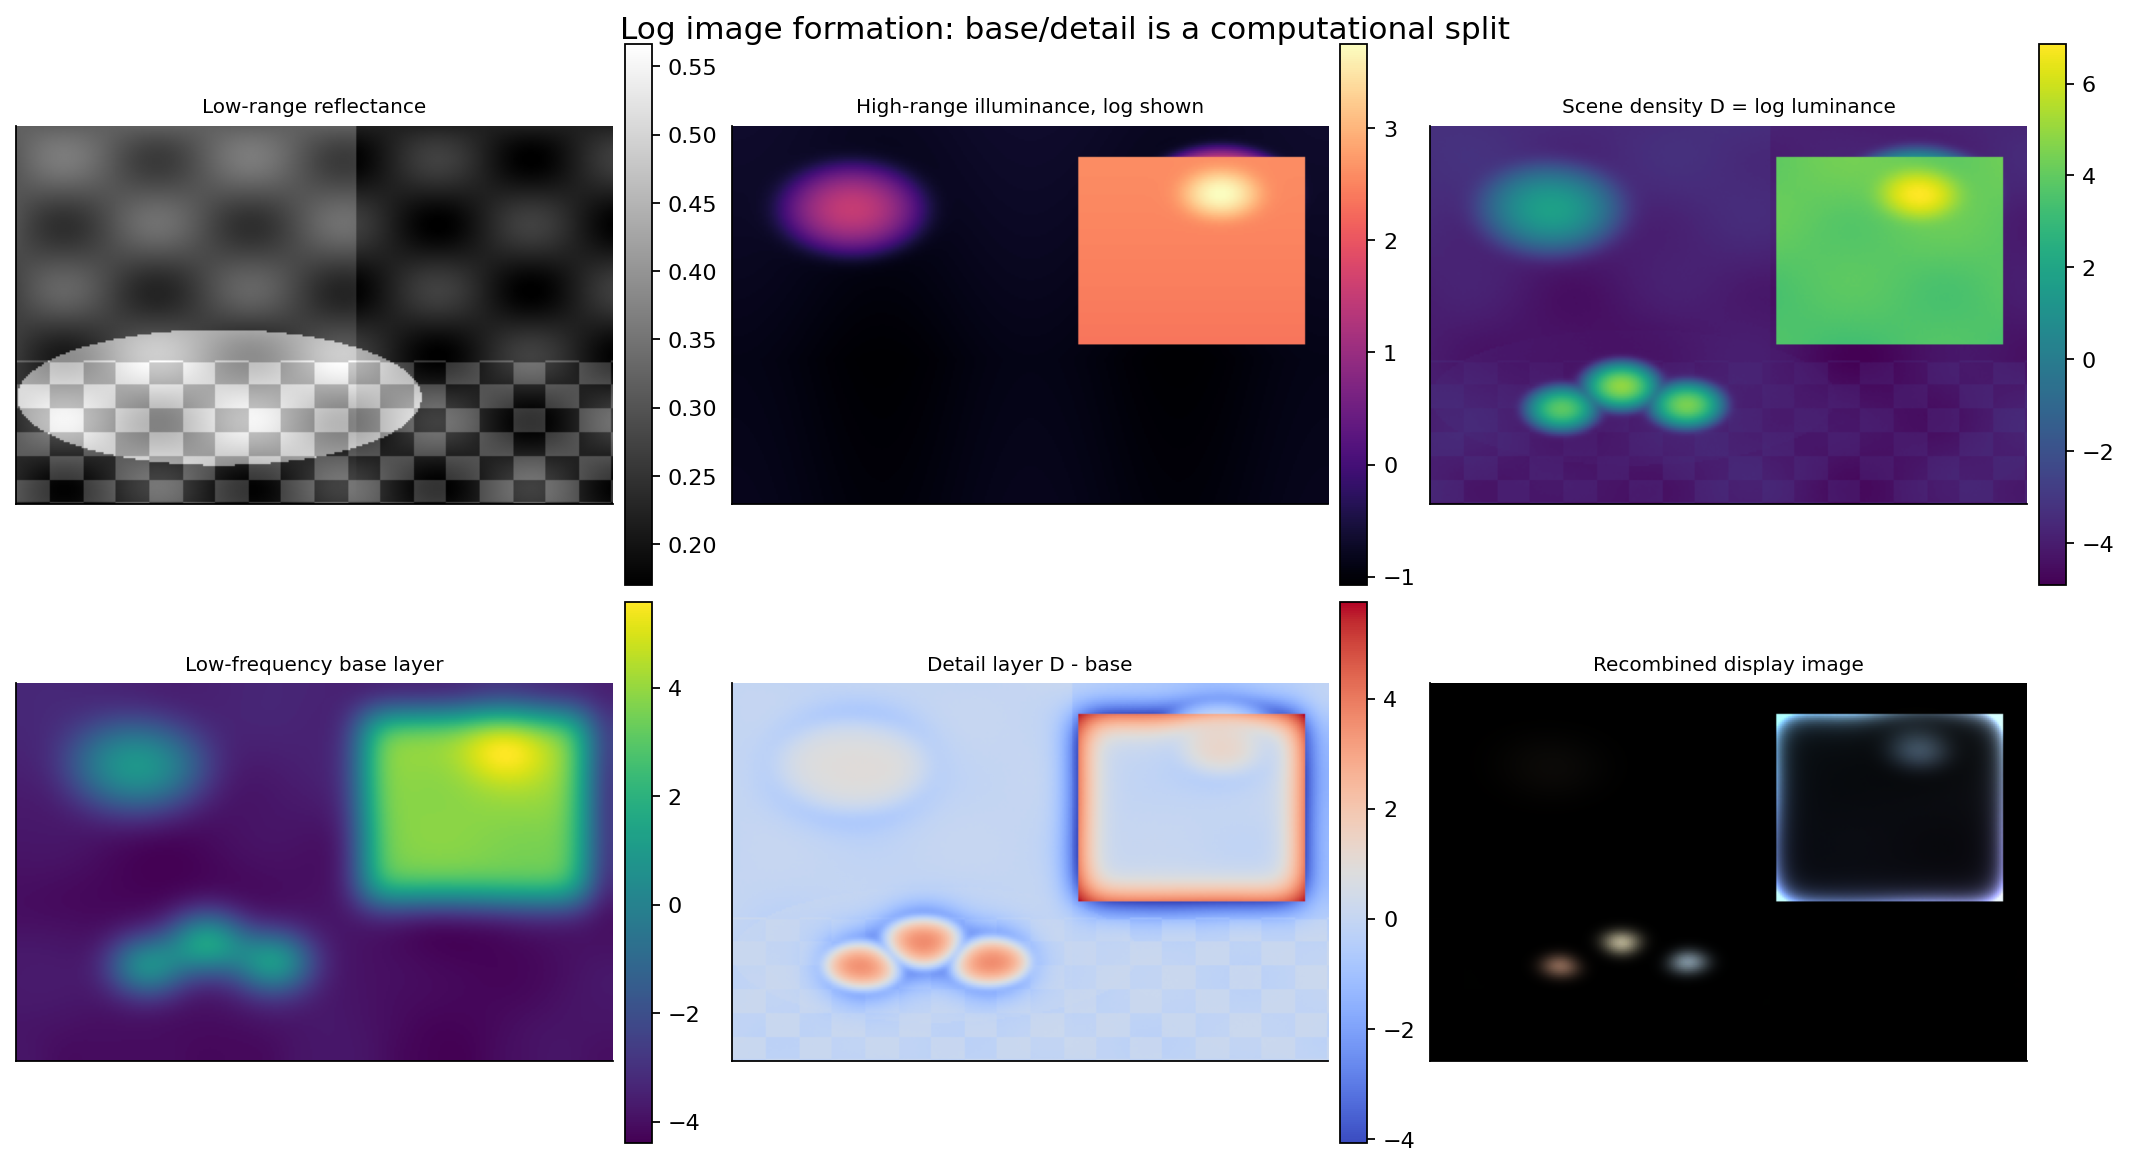

In [7]:
D = np.log(np.maximum(scene_L, 1e-8))
base_gaussian = ndimage.gaussian_filter(D, sigma=9.0, mode="reflect")
detail_gaussian = D - base_gaussian
compressed_density = detail_gaussian + 0.36 * base_gaussian
compressed_density -= np.quantile(compressed_density, 0.001)
formation_L = normalize01(np.exp(compressed_density), 0.001, 0.999)
formation_rgb = display_from_luminance(scene_rgb, formation_L)
add_operator_metric("log base/detail compression", formation_rgb, reference_rgb=scene_rgb, notes="Gaussian base compressed in density space")

fig, axes = plt.subplots(2, 3, figsize=(13.2, 7.0), constrained_layout=True)
formation_panels = [
    ("Low-range reflectance", reflectance, "gray"),
    ("High-range illuminance, log shown", np.log10(illuminance + 1e-8), "magma"),
    ("Scene density D = log luminance", D, "viridis"),
    ("Low-frequency base layer", base_gaussian, "viridis"),
    ("Detail layer D - base", detail_gaussian, "coolwarm"),
    ("Recombined display image", formation_rgb, None),
]
for ax, (title, data, cmap) in zip(axes.ravel(), formation_panels):
    if cmap is None:
        ax.imshow(np.clip(data, 0, 1))
    else:
        im = ax.imshow(data, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Log image formation: base/detail is a computational split", y=1.02, fontsize=14)
formation_path = remember(save_matplotlib(fig, TOPIC, "image-formation-log-base-detail.png"), "image")
plt.close(fig)

display_artifact(formation_path, width=940)

In [8]:
assert reflectance_range["stops"] < illuminance_range["stops"]
assert robust_range(luminance(formation_rgb))["stops"] < scene_range["stops"]
{
    "reflectance_stops": reflectance_range["stops"],
    "illuminance_stops": illuminance_range["stops"],
    "compressed_density_display_stops": robust_range(luminance(formation_rgb))["stops"],
}

{'reflectance_stops': 1.7046047461264489,
 'illuminance_stops': 15.76738446830818,
 'compressed_density_display_stops': 15.395990936896562}

## 5. Frequency and gradient-domain operators

A frequency-domain operator compresses a low-frequency base and keeps a high-frequency detail layer. A gradient-domain operator changes the derivative field first, then reconstructs an image whose gradients match the edited field. Both are rooted in the same image-formation intuition: illumination tends to vary slowly, while reflectance and object boundaries create localized changes.

Highlights complicate this story. A visible light source is both a high luminance value and a sharp edge. The gradient example attenuates large density gradients before solving a small periodic Poisson problem, which is a compact version of the integration step described in the chapter.

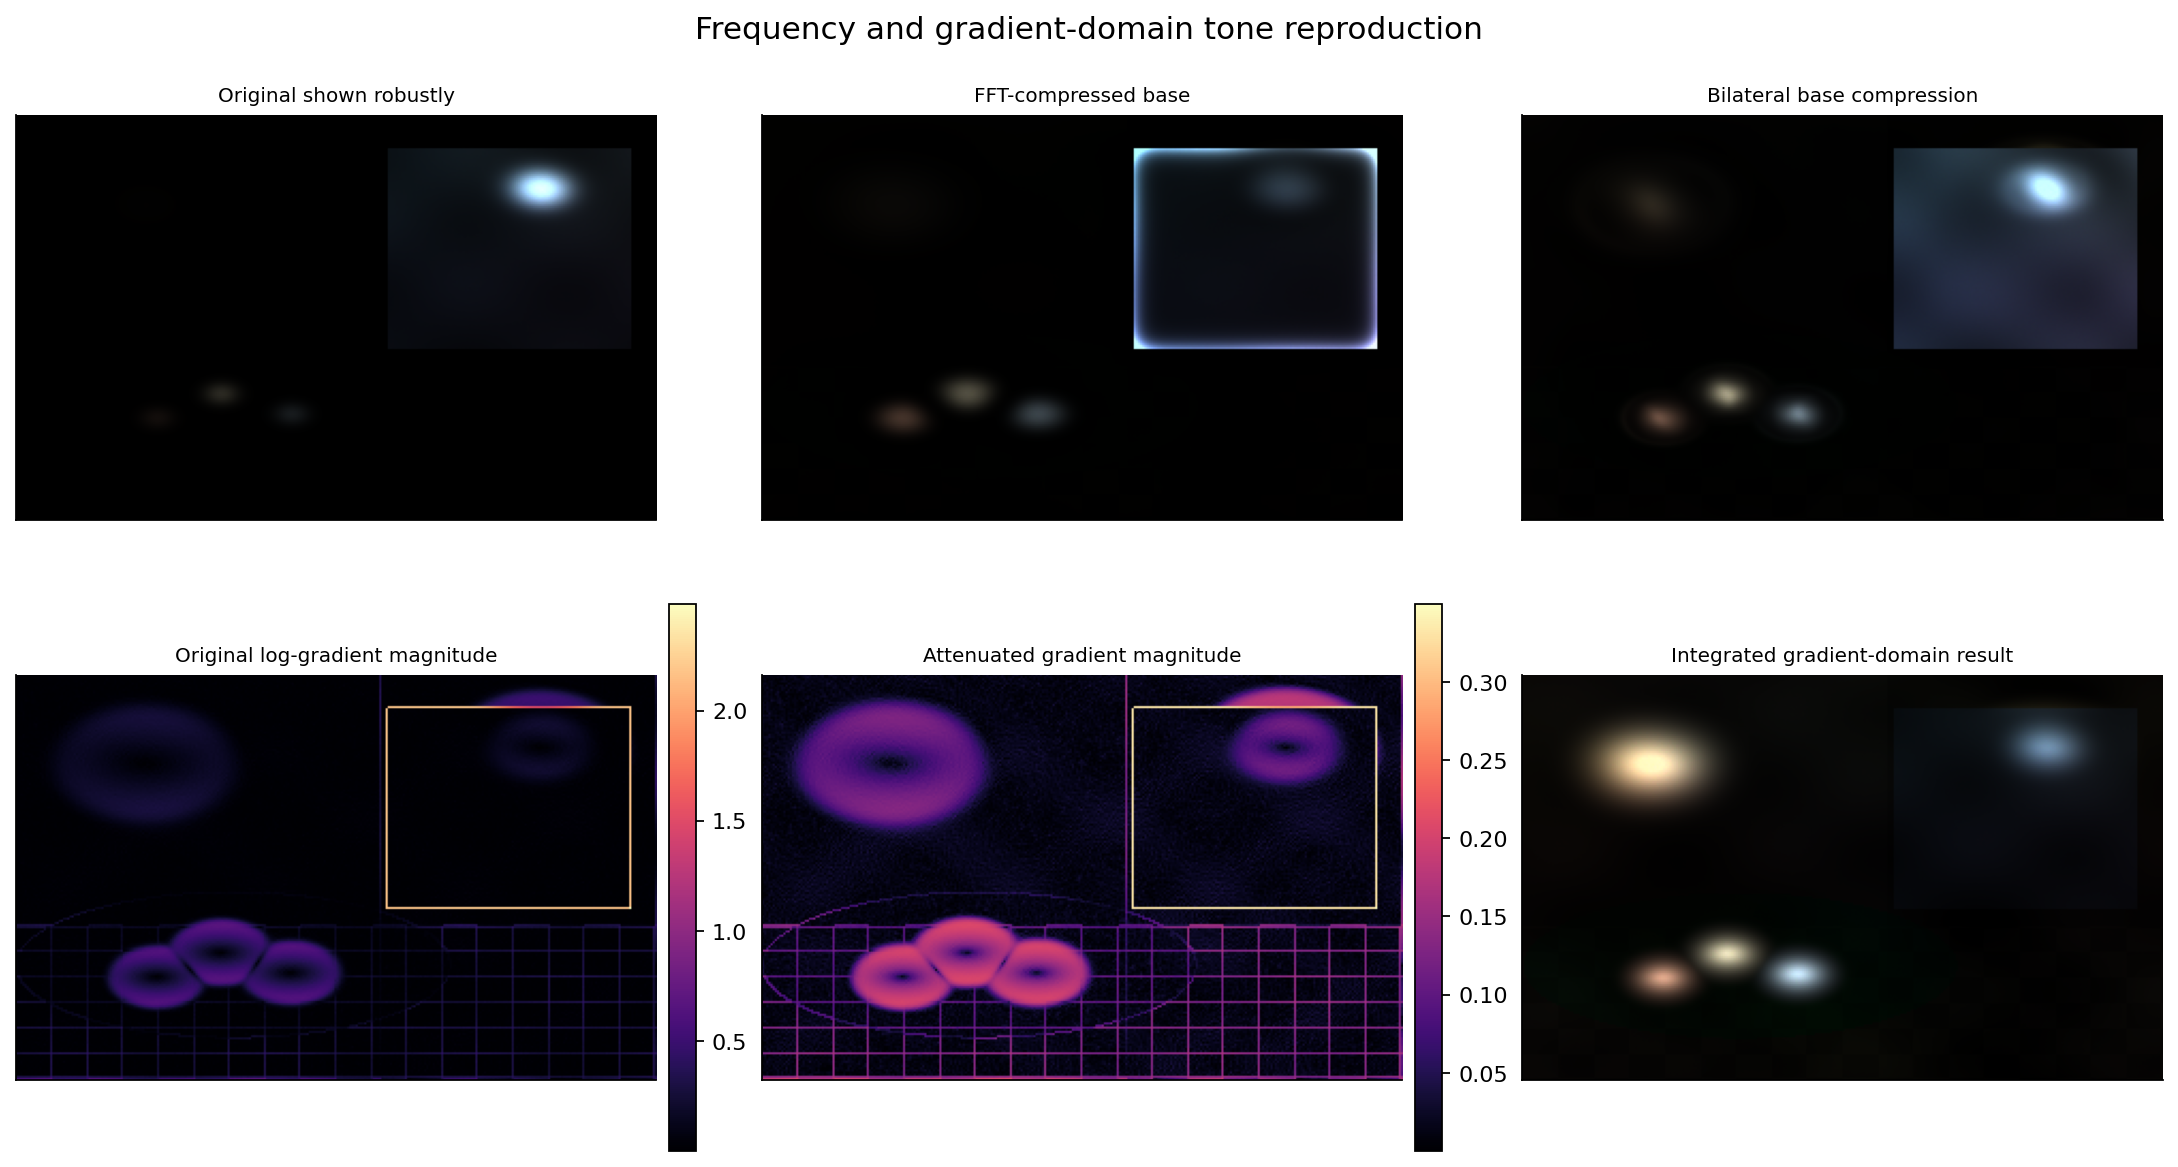

{'gradient_residual': 0.0068661057490119574,
 'source_gradient_norm': 0.6713122539375647,
 'compressed_gradient_norm': 0.07386843494992572}

In [9]:
def periodic_forward_gradient(U):
    gx = np.roll(U, -1, axis=1) - U
    gy = np.roll(U, -1, axis=0) - U
    return gx, gy

def periodic_divergence(gx, gy):
    return gx - np.roll(gx, 1, axis=1) + gy - np.roll(gy, 1, axis=0)

def solve_periodic_poisson(div, target_mean=0.0):
    h, w = div.shape
    ky = 2 * np.pi * fftfreq(h)[:, None]
    kx = 2 * np.pi * fftfreq(w)[None, :]
    eigen = 2 * np.cos(kx) + 2 * np.cos(ky) - 4
    div_hat = fft2(div)
    out_hat = np.zeros_like(div_hat, dtype=complex)
    mask = np.abs(eigen) > 1e-12
    out_hat[mask] = div_hat[mask] / eigen[mask]
    out = ifft2(out_hat).real
    out -= np.mean(out)
    out += target_mean
    return out

centered_D = D - np.mean(D)
h, w = D.shape
fy = fftfreq(h)[:, None]
fx = fftfreq(w)[None, :]
radius = np.sqrt(fx**2 + fy**2)
lowpass = np.exp(-(radius / 0.035) ** 2)
D_base_fft = ifft2(fft2(centered_D) * lowpass).real + np.mean(D)
D_detail_fft = D - D_base_fft
D_frequency = 0.34 * D_base_fft + D_detail_fft
frequency_L = normalize01(np.exp(D_frequency), 0.001, 0.999)
frequency_rgb = display_from_luminance(scene_rgb, frequency_L)
add_operator_metric("frequency base compression", frequency_rgb, reference_rgb=scene_rgb, notes="FFT low-frequency base attenuated")

gx, gy = periodic_forward_gradient(D)
mag = np.hypot(gx, gy)
tau = np.quantile(mag, 0.88)
attenuation = 1.0 / (1.0 + (mag / max(tau, 1e-9)) ** 0.85)
gx_c = gx * attenuation
gy_c = gy * attenuation
D_gradient = solve_periodic_poisson(periodic_divergence(gx_c, gy_c), target_mean=float(np.mean(D)))
gradient_L = normalize01(np.exp(D_gradient), 0.001, 0.999)
gradient_rgb = display_from_luminance(scene_rgb, gradient_L)
add_operator_metric("gradient compression", gradient_rgb, reference_rgb=scene_rgb, notes="large log gradients attenuated then integrated")

D_min, D_ptp = float(np.min(D)), float(np.ptp(D))
D_unit = (D - D_min) / D_ptp
D_bilateral_unit = denoise_bilateral(D_unit, sigma_color=0.09, sigma_spatial=8, channel_axis=None)
D_bilateral_base = D_bilateral_unit * D_ptp + D_min
D_bilateral_detail = D - D_bilateral_base
D_bilateral = 0.36 * D_bilateral_base + D_bilateral_detail
bilateral_L = normalize01(np.exp(D_bilateral), 0.001, 0.999)
bilateral_rgb = display_from_luminance(scene_rgb, bilateral_L)
add_operator_metric("bilateral base compression", bilateral_rgb, reference_rgb=scene_rgb, notes="edge-preserving base compressed")

reconstructed_gx, reconstructed_gy = periodic_forward_gradient(D_gradient)
gradient_residual = float(np.sqrt(np.mean((reconstructed_gx - gx_c) ** 2 + (reconstructed_gy - gy_c) ** 2)))
source_grad_norm = float(np.sqrt(np.mean(gx ** 2 + gy ** 2)))
compressed_grad_norm = float(np.sqrt(np.mean(gx_c ** 2 + gy_c ** 2)))

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.0), constrained_layout=True)
panels = [
    ("Original shown robustly", normalize01(scene_rgb), None),
    ("FFT-compressed base", frequency_rgb, None),
    ("Bilateral base compression", bilateral_rgb, None),
    ("Original log-gradient magnitude", np.log1p(mag), "magma"),
    ("Attenuated gradient magnitude", np.log1p(np.hypot(gx_c, gy_c)), "magma"),
    ("Integrated gradient-domain result", gradient_rgb, None),
]
for ax, (title, data, cmap) in zip(axes.ravel(), panels):
    if cmap is None:
        ax.imshow(np.clip(data, 0, 1))
    else:
        im = ax.imshow(data, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Frequency and gradient-domain tone reproduction", y=1.02, fontsize=14)
fg_path = remember(save_matplotlib(fig, TOPIC, "frequency-gradient-operator-comparison.png"), "image")
plt.close(fig)

display_artifact(fg_path, width=940)
{
    "gradient_residual": gradient_residual,
    "source_gradient_norm": source_grad_norm,
    "compressed_gradient_norm": compressed_grad_norm,
}

The residual is not expected to be zero: after attenuation, the edited gradient field may not be perfectly integrable. The Poisson solve finds the image whose gradients best match that edited field in the least-squares sense. The important invariant for this lesson is that the operator reduces extreme gradients and compresses the display range without simply clipping the highlights.

In [10]:
assert compressed_grad_norm < source_grad_norm
assert gradient_residual < 0.40 * source_grad_norm
assert robust_range(luminance(gradient_rgb))["stops"] < scene_range["stops"]

## 6. Spatial operators, local adaptation, and halos

Spatial operators apply compression directly to pixels. A global operator uses the same curve everywhere, often anchored by the geometric mean. A local operator changes the divisor or semi-saturation value from neighborhood statistics. The benefit is local contrast. The cost is that the neighborhood can cross a strong edge, so the local average no longer describes either side well. That mismatch appears as a halo.

Division by a blurred image is especially sensitive to halos. A local sigmoid is more forgiving because the blurred value moves the half-response point instead of directly dividing the pixel value. Edge-preserving bilateral filtering can also compute a local adaptation map without averaging straight across sharp steps.

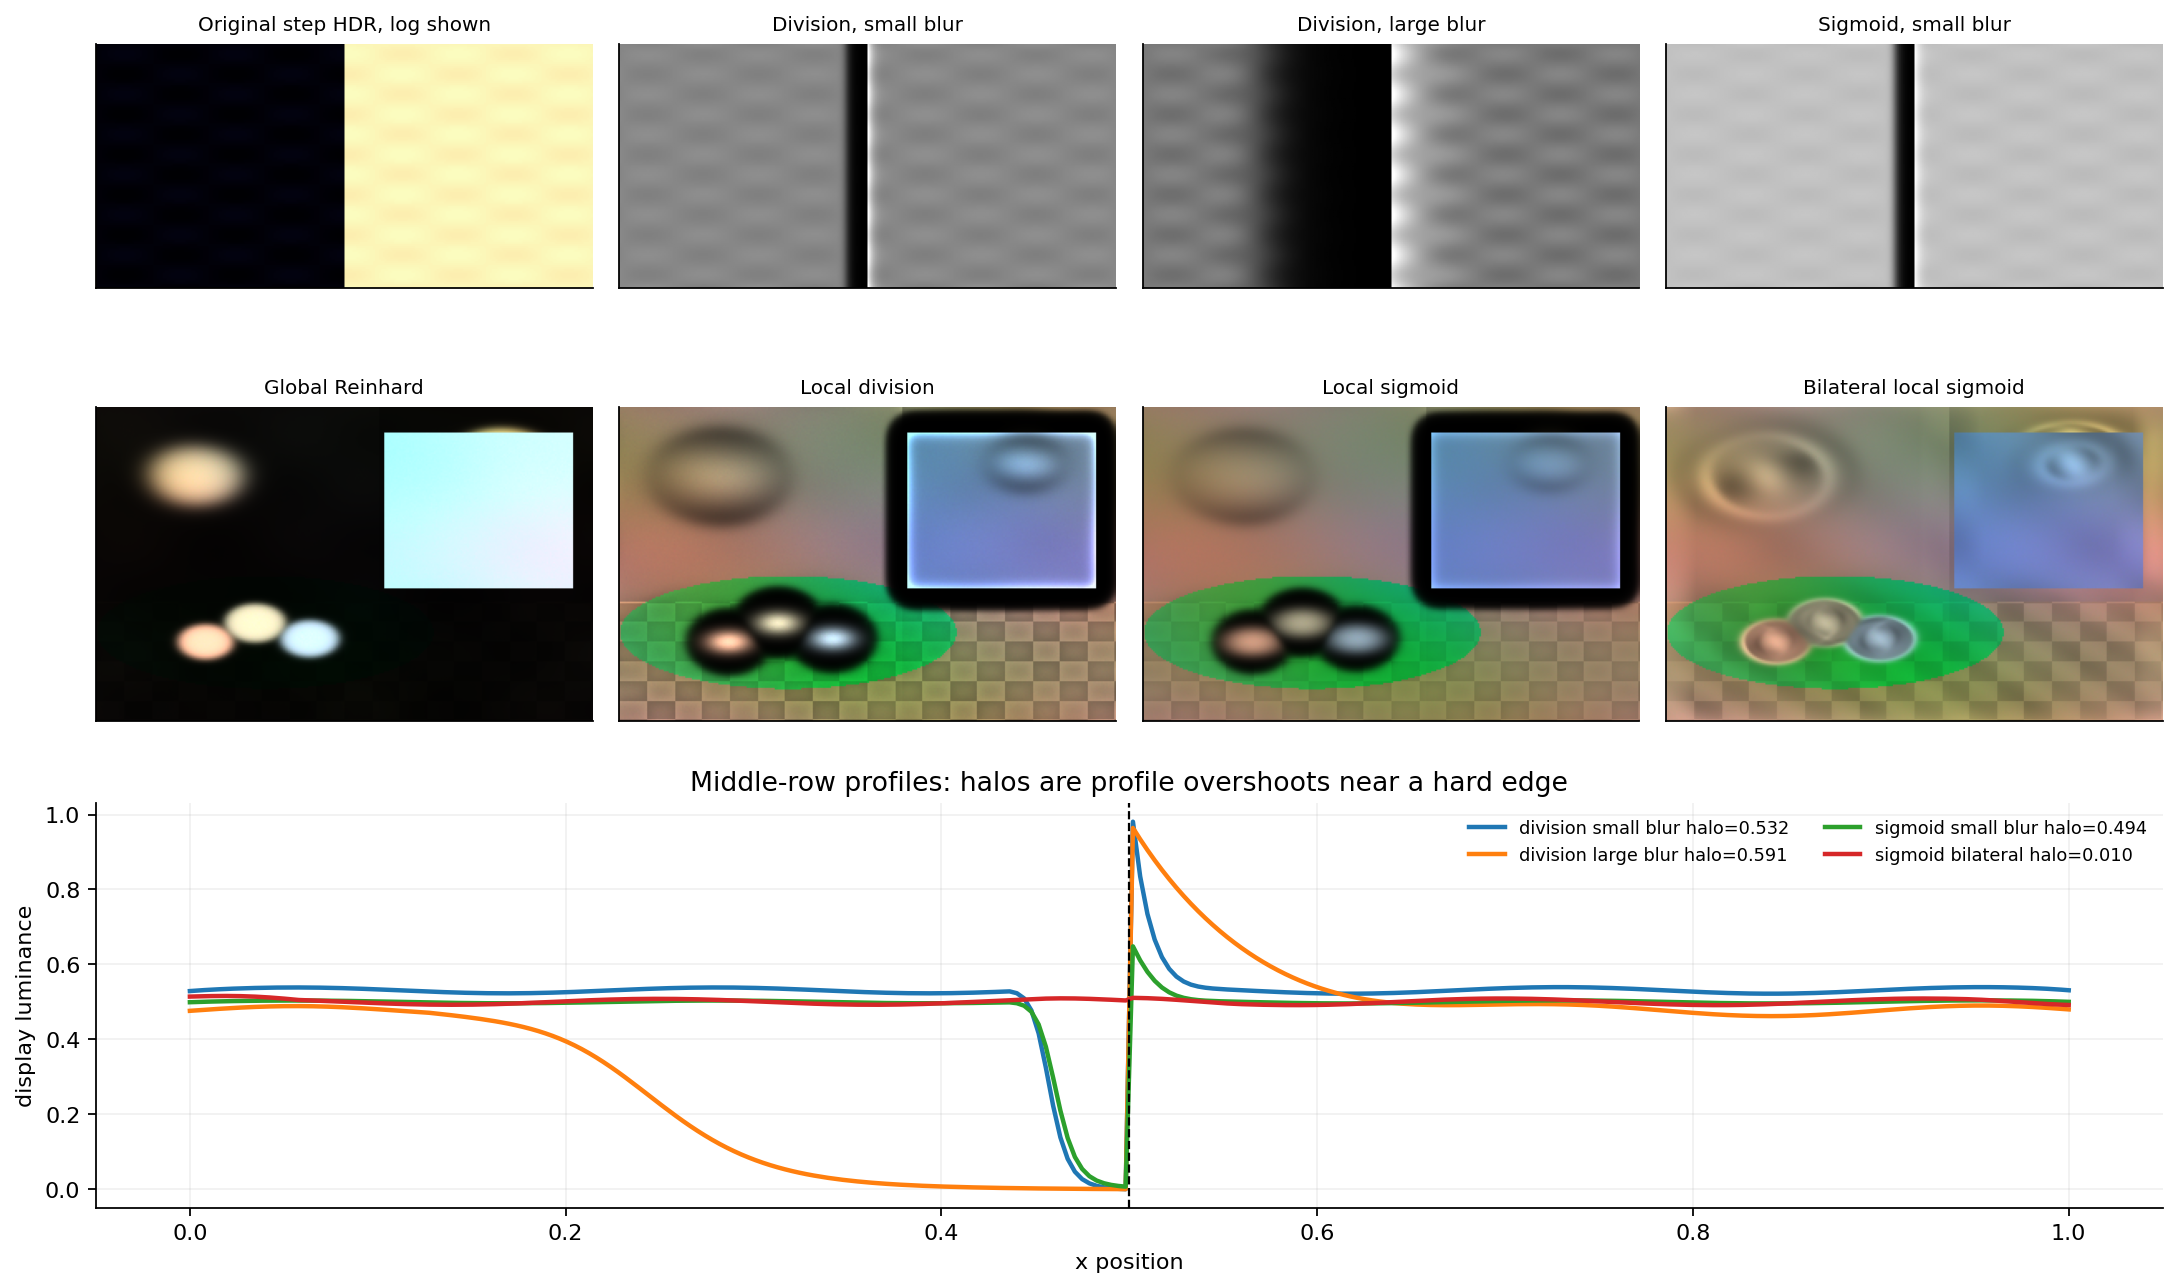

{'division small blur': 0.5317191047358139,
 'division large blur': 0.5906256726147869,
 'sigmoid small blur': 0.49358743282106254,
 'sigmoid bilateral': 0.009786827547570764}

In [11]:
small_blur = ndimage.gaussian_filter(scene_L, sigma=4.0, mode="reflect")
large_blur = ndimage.gaussian_filter(scene_L, sigma=24.0, mode="reflect")
local_division_L = normalize01(scene_L / (small_blur + 1e-6), 0.001, 0.999)
local_division_rgb = display_from_luminance(scene_rgb, local_division_L)
local_sigmoid_L = sigmoid_luminance(scene_L, np.maximum(small_blur, 1e-6), n=1.0)
local_sigmoid_rgb = display_from_luminance(scene_rgb, local_sigmoid_L)

log_scene_unit = (D - D_min) / D_ptp
local_bilateral_unit = denoise_bilateral(log_scene_unit, sigma_color=0.07, sigma_spatial=6, channel_axis=None)
local_bilateral_f = np.exp(local_bilateral_unit * D_ptp + D_min)
bilateral_sigmoid_L = sigmoid_luminance(scene_L, local_bilateral_f, n=1.0)
bilateral_sigmoid_rgb = display_from_luminance(scene_rgb, bilateral_sigmoid_L)

add_operator_metric("local division small blur", local_division_rgb, reference_rgb=scene_rgb, notes="division by Gaussian local average")
add_operator_metric("local sigmoid Gaussian", local_sigmoid_rgb, reference_rgb=scene_rgb, notes="Gaussian semi-saturation map")
add_operator_metric("local sigmoid bilateral", bilateral_sigmoid_rgb, reference_rgb=scene_rgb, notes="edge-preserving semi-saturation map")

EH, EW = 128, 260
ex = np.linspace(0, 1, EW)
ey = np.linspace(0, 1, EH)
EX, EY = np.meshgrid(ex, ey)
edge_L = np.where(EX < 0.50, 0.25, 90.0)
edge_L *= 1.0 + 0.10 * np.sin(38 * EY) * np.sin(28 * EX)
edge_L += 0.03
edge_small = ndimage.gaussian_filter(edge_L, sigma=4.0, mode="reflect")
edge_large = ndimage.gaussian_filter(edge_L, sigma=24.0, mode="reflect")
edge_bilateral_unit = denoise_bilateral(normalize01(np.log(edge_L)), sigma_color=0.08, sigma_spatial=5, channel_axis=None)
edge_bilateral = np.exp(edge_bilateral_unit * np.ptp(np.log(edge_L)) + np.min(np.log(edge_L)))
edge_div_small = normalize01(edge_L / (edge_small + 1e-6), 0.001, 0.999)
edge_div_large = normalize01(edge_L / (edge_large + 1e-6), 0.001, 0.999)
edge_sig_small = sigmoid_luminance(edge_L, edge_small, n=1.0)
edge_sig_bilat = sigmoid_luminance(edge_L, edge_bilateral, n=1.0)
mid = EH // 2
band = slice(EW // 2 - 22, EW // 2 + 22)
far_left = slice(EW // 2 - 90, EW // 2 - 45)
far_right = slice(EW // 2 + 45, EW // 2 + 90)

def halo_score(profile):
    left_base = np.mean(profile[far_left])
    right_base = np.mean(profile[far_right])
    baseline = np.linspace(left_base, right_base, band.stop - band.start)
    return float(np.max(np.abs(profile[band] - baseline)))

halo_scores = {
    "division small blur": halo_score(edge_div_small[mid]),
    "division large blur": halo_score(edge_div_large[mid]),
    "sigmoid small blur": halo_score(edge_sig_small[mid]),
    "sigmoid bilateral": halo_score(edge_sig_bilat[mid]),
}

fig = plt.figure(figsize=(13.5, 8.2), constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 1.05])
image_panels = [
    ("Original step HDR, log shown", np.log10(edge_L), "magma"),
    ("Division, small blur", edge_div_small, "gray"),
    ("Division, large blur", edge_div_large, "gray"),
    ("Sigmoid, small blur", edge_sig_small, "gray"),
    ("Global Reinhard", reinhard_rgb, None),
    ("Local division", local_division_rgb, None),
    ("Local sigmoid", local_sigmoid_rgb, None),
    ("Bilateral local sigmoid", bilateral_sigmoid_rgb, None),
]
for idx, (title, data, cmap) in enumerate(image_panels):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])
    if cmap is None:
        ax.imshow(np.clip(data, 0, 1))
    else:
        ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

ax = fig.add_subplot(gs[2, :])
for name, profile in [
    ("division small blur", edge_div_small[mid]),
    ("division large blur", edge_div_large[mid]),
    ("sigmoid small blur", edge_sig_small[mid]),
    ("sigmoid bilateral", edge_sig_bilat[mid]),
]:
    ax.plot(ex, profile, lw=2, label=f"{name} halo={halo_scores[name]:.3f}")
ax.axvline(0.5, color="black", ls="--", lw=1)
ax.set_title("Middle-row profiles: halos are profile overshoots near a hard edge")
ax.set_xlabel("x position")
ax.set_ylabel("display luminance")
ax.legend(frameon=False, ncols=2, fontsize=8)

spatial_path = remember(save_matplotlib(fig, TOPIC, "spatial-local-adaptation-halos.png"), "image")
plt.close(fig)
display_artifact(spatial_path, width=960)
halo_scores

In [12]:
assert halo_scores["sigmoid small blur"] < halo_scores["division small blur"]
assert halo_scores["sigmoid bilateral"] <= halo_scores["sigmoid small blur"] * 1.25

## 7. Color preservation and saturation choices

Most operators compress luminance, then reconstruct color from the original channel ratios. If the parameter `s` is one, the pre-clipping RGB-to-luminance ratios are preserved exactly. This often looks too saturated when a bright scene is displayed in a dim surround, so smaller `s` values intentionally desaturate the result. A per-channel sigmoid is another possibility, but it changes chromaticities because each channel is compressed by its own magnitude.

The plot below separates the numerical invariant from the appearance choice. Ratio preservation is not automatically the same as preferred color appearance.

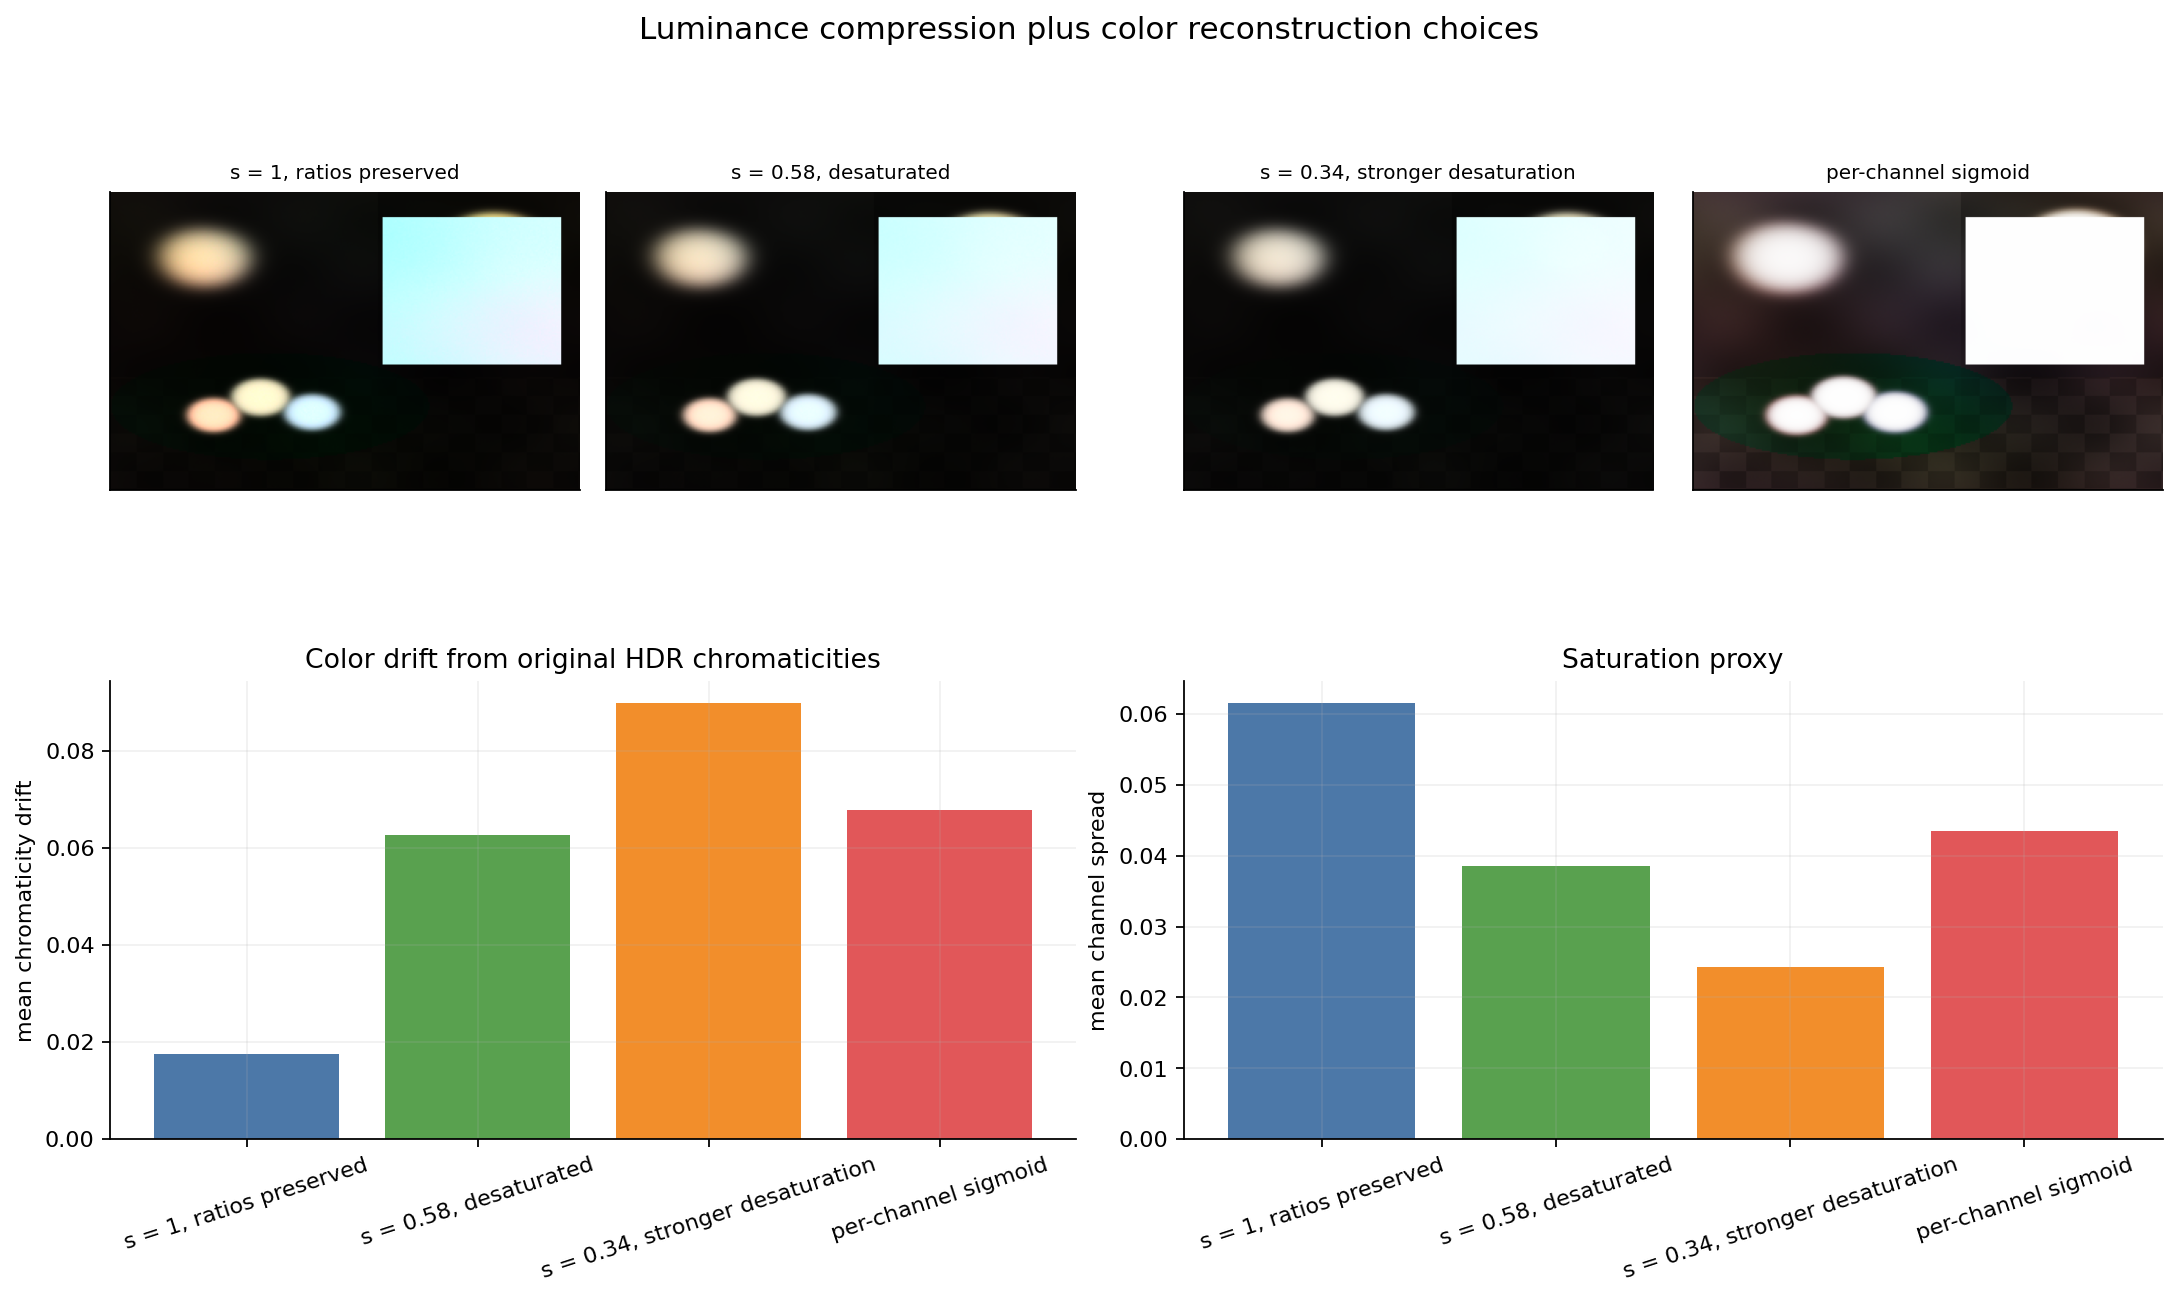

{'ratio_preservation_error_before_clipping': 1.2927927668640058e-08,
 'chroma_errors': {'s = 1, ratios preserved': 0.017610549288088636,
  's = 0.58, desaturated': 0.0626446772879972,
  's = 0.34, stronger desaturation': 0.0899351727523748,
  'per-channel sigmoid': 0.0678149172060747}}

In [13]:
Ld_color = reinhard_global_luminance(scene_L, key=0.22)
ratio_preserving_unclipped = display_from_luminance(scene_rgb, Ld_color, s=1.0, clip=False)
ratio_preserving = np.clip(ratio_preserving_unclipped, 0.0, 1.0)
desaturated = display_from_luminance(scene_rgb, Ld_color, s=0.58, clip=True)
more_desaturated = display_from_luminance(scene_rgb, Ld_color, s=0.34, clip=True)
channel_f_vec = np.exp(np.mean(np.log(np.maximum(scene_rgb.reshape(-1, 3), 1e-6)), axis=0))
per_channel_sigmoid = scene_rgb / (scene_rgb + channel_f_vec.reshape(1, 1, 3))
per_channel_sigmoid = np.clip(per_channel_sigmoid, 0.0, 1.0)

L_original = scene_L
ratio_original = scene_rgb / (L_original[..., None] + 1e-9)
ratio_after = ratio_preserving_unclipped / (luminance(ratio_preserving_unclipped)[..., None] + 1e-9)
ratio_preservation_error = float(np.mean(np.abs(ratio_original - ratio_after)))

color_variants = [
    ("s = 1, ratios preserved", ratio_preserving),
    ("s = 0.58, desaturated", desaturated),
    ("s = 0.34, stronger desaturation", more_desaturated),
    ("per-channel sigmoid", per_channel_sigmoid),
]
for title, img in color_variants:
    add_operator_metric(title, img, reference_rgb=scene_rgb, notes="color reconstruction variant")

chroma_errors = {title: float(np.mean(np.linalg.norm(chromaticity(img) - chromaticity(scene_rgb), axis=-1))) for title, img in color_variants}
mean_saturation = {title: float(np.mean(np.max(img, axis=-1) - np.min(img, axis=-1))) for title, img in color_variants}

fig = plt.figure(figsize=(13.5, 7.8), constrained_layout=True)
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 0.78])
for i, (title, img) in enumerate(color_variants):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

ax = fig.add_subplot(gs[1, :2])
ax.bar(chroma_errors.keys(), chroma_errors.values(), color=["#4c78a8", "#59a14f", "#f28e2b", "#e15759"])
ax.set_ylabel("mean chromaticity drift")
ax.set_title("Color drift from original HDR chromaticities")
ax.tick_params(axis="x", rotation=18)

ax = fig.add_subplot(gs[1, 2:])
ax.bar(mean_saturation.keys(), mean_saturation.values(), color=["#4c78a8", "#59a14f", "#f28e2b", "#e15759"])
ax.set_ylabel("mean channel spread")
ax.set_title("Saturation proxy")
ax.tick_params(axis="x", rotation=18)

fig.suptitle("Luminance compression plus color reconstruction choices", y=1.02, fontsize=14)
color_path = remember(save_matplotlib(fig, TOPIC, "color-preservation-saturation.png"), "image")
plt.close(fig)

display_artifact(color_path, width=940)
{"ratio_preservation_error_before_clipping": ratio_preservation_error, "chroma_errors": chroma_errors}

In [14]:
assert ratio_preservation_error < 1e-7
assert mean_saturation["s = 0.34, stronger desaturation"] < mean_saturation["s = 1, ratios preserved"]
assert chroma_errors["per-channel sigmoid"] > chroma_errors["s = 1, ratios preserved"]

## 8. Night tone reproduction

Night mapping is an appearance operator. It is not just a lower exposure. Under scotopic viewing, acuity drops, perceived contrast drops, and colors move toward a bluish-gray appearance. The notebook implements a compact version of that pipeline: transform linear RGB to XYZ, compute a scotopic luminance-like channel, map it to display, tint it blue-gray, blend back photopic pixels for bright regions, and use bilateral filtering to reduce fine detail while keeping the largest edges legible.

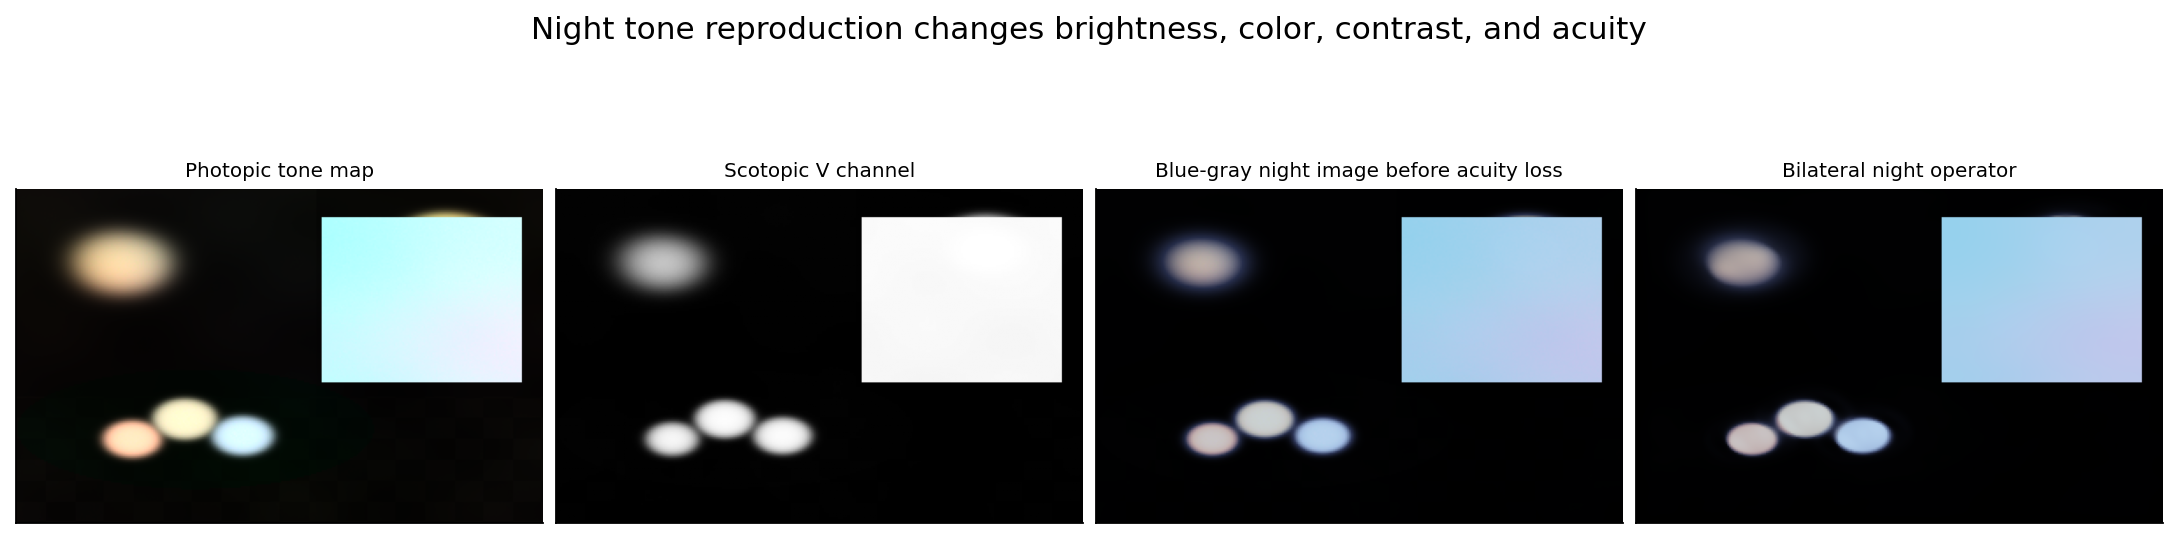

{'photopic_mean_luminance': 0.2526197115796848,
 'night_mean_luminance': 0.18177369067050245,
 'photopic_mean_saturation': 0.0591760997073721,
 'night_mean_saturation': 0.05641700758417187,
 'photopic_contrast': 0.013329449407608085,
 'night_contrast': 0.01022293248139397}

In [15]:
RGB_TO_XYZ = np.array([
    [0.4124564, 0.3575761, 0.1804375],
    [0.2126729, 0.7151522, 0.0721750],
    [0.0193339, 0.1191920, 0.9503041],
])
xyz = scene_rgb @ RGB_TO_XYZ.T
Xc = np.maximum(xyz[..., 0], 1e-6)
Yc = np.maximum(xyz[..., 1], 0.0)
Zc = np.maximum(xyz[..., 2], 0.0)
scotopic_V = Yc * (1.33 * (1.0 + (Yc + Zc) / Xc) - 1.68)
scotopic_V = np.maximum(scotopic_V, 0.0)
night_L = reinhard_global_luminance(scotopic_V + 1e-6, key=0.10)
night_L = np.power(night_L, 1.18)
blue_gray = np.array([0.42, 0.50, 0.82])
night_blue = night_L[..., None] * blue_gray.reshape(1, 1, 3)
photopic_display = reinhard_rgb
blend = np.clip((reinhard_L - 0.58) / 0.32, 0.0, 1.0)[..., None]
night_mixed = (1.0 - blend) * night_blue + blend * (0.35 * night_blue + 0.65 * photopic_display)
night_bilateral = denoise_bilateral(np.clip(night_mixed, 0, 1), sigma_color=0.045, sigma_spatial=3, channel_axis=-1)
night_rgb = np.clip(night_bilateral, 0.0, 1.0)
add_operator_metric("scotopic night operator", night_rgb, reference_rgb=scene_rgb, notes="blue shift, lower contrast, acuity loss")

fig, axes = plt.subplots(1, 4, figsize=(13.5, 4.1), constrained_layout=True)
panels = [
    ("Photopic tone map", photopic_display),
    ("Scotopic V channel", night_L, "gray"),
    ("Blue-gray night image before acuity loss", night_mixed),
    ("Bilateral night operator", night_rgb),
]
for ax, panel in zip(axes, panels):
    title = panel[0]
    data = panel[1]
    cmap = panel[2] if len(panel) > 2 else None
    if cmap:
        ax.imshow(data, cmap=cmap)
    else:
        ax.imshow(data)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Night tone reproduction changes brightness, color, contrast, and acuity", y=1.02, fontsize=14)
night_path = remember(save_matplotlib(fig, TOPIC, "scotopic-night-operator.png"), "image")
plt.close(fig)

display_artifact(night_path, width=940)

night_stats = {
    "photopic_mean_luminance": float(np.mean(luminance(photopic_display))),
    "night_mean_luminance": float(np.mean(luminance(night_rgb))),
    "photopic_mean_saturation": float(np.mean(np.max(photopic_display, axis=-1) - np.min(photopic_display, axis=-1))),
    "night_mean_saturation": float(np.mean(np.max(night_rgb, axis=-1) - np.min(night_rgb, axis=-1))),
    "photopic_contrast": local_contrast_score(photopic_display),
    "night_contrast": local_contrast_score(night_rgb),
}
night_stats

In [16]:
assert night_stats["night_mean_luminance"] < night_stats["photopic_mean_luminance"]
assert night_stats["night_contrast"] < night_stats["photopic_contrast"]
assert night_stats["night_mean_saturation"] <= night_stats["photopic_mean_saturation"] * 1.05

## 9. Applied lab: choose an operator from constraints

Use the generated metrics as a design ledger. A real renderer would choose an operator from constraints:

- Real-time preview: prefer a global sigmoid or log map, then accept weaker local detail.
- Offline still image with extreme range: use bilateral base compression or local sigmoid adaptation.
- Diagnostic render where highlights matter: avoid aggressive clamping and inspect gradient attenuation.
- Color-critical review: separate luminance compression from color appearance; check chromaticity drift instead of trusting the image by eye.
- Night simulation: use an appearance operator because a darker exposure does not model scotopic acuity or color shift.

The lab cell below saves the ledger used by the final checks. Add a new operator by registering an RGB display image with `add_operator_metric` and rerunning the ledger.

In [17]:
ledger = pd.DataFrame(metrics_rows)
ordered_columns = [
    "operator",
    "luminance_log10_range",
    "luminance_stops",
    "clipped_fraction",
    "mean_gradient",
    "mean_chromaticity_error",
    "notes",
]
for col in ordered_columns:
    if col not in ledger.columns:
        ledger[col] = np.nan
ledger = ledger[ordered_columns].sort_values("operator").reset_index(drop=True)
ledger_path = remember(save_table_csv(ledger.to_dict(orient="records"), TOPIC, "tone-reproduction-check-ledger.csv"), "table")
display_artifact(ledger_path)
ledger

,operator,luminance_log10_range,luminance_stops,clipped_fraction,mean_gradient,mean_chromaticity_error,notes
0,bilateral base compression,3.855650,12.808192,0.002199,0.003905,6.837966e-04,edge-preserving base compressed
1,clamp at white point,4.719798,15.678829,0.005000,0.002819,3.528414e-04,clips highlights above selected white
2,exposure +3 stops,1.214624,4.034895,0.274094,0.016231,3.105522e-02,plain exposure preview
3,exposure -1 stop,2.418744,8.034895,0.222865,0.013856,2.669829e-02,plain exposure preview
4,exposure -5 stops,3.622864,12.034895,0.182146,0.010452,2.390248e-02,plain exposure preview
5,frequency base compression,4.400220,14.617213,0.001959,0.008004,7.128943e-04,FFT low-frequency base attenuated
6,global Reinhard,1.987823,6.603404,0.096585,0.013329,1.744332e-02,global bounded sigmoid after key scaling
7,gradient compression,3.250655,10.798441,0.001936,0.005370,6.446273e-04,large log gradients attenuated then integrated
8,linear normalize,5.014652,16.658313,0.000018,0.001616,4.987195e-05,divides by global maximum
9,local division small blur,4.420284,14.683866,0.007018,0.026980,1.386476e-03,division by Gaussian local average


## Sanity checks and Takeaways

The final cell checks the mathematical and artifact-level invariants that make this notebook reproducible:

- the source HDR array has more range than the core compressive operator outputs;
- the sigmoid half-response identity holds;
- the diffuse reflectance component is lower range than the illuminance component;
- the gradient operator actually attenuates gradient energy and reconstructs a bounded image;
- color-ratio reconstruction with `s=1` preserves ratios before clipping;
- local adaptation halo behavior is measured rather than only described;
- every concept-named artifact exists and nonblank image artifacts have nonzero variation.

Takeaway: tone reproduction is controlled loss. The operator should make the loss explicit: clipping loses bright values, global curves lose local contrast, local operators risk halos, color reconstruction can preserve or adapt chromaticity, and night operators model a different visual regime.

In [18]:
expected_images = [
    range_path,
    curve_png,
    exposure_path,
    formation_path,
    fg_path,
    spatial_path,
    color_path,
    night_path,
]
expected_html = [curve_html]
expected_tables = [ledger_path]

operator_range_checks = {
    name: robust_range(luminance(img))["stops"] for name, img in operator_outputs.items()
}
core_compressive_names = [
    "global Reinhard",
    "log compression",
    "log base/detail compression",
    "frequency base compression",
    "gradient compression",
    "bilateral base compression",
    "local sigmoid Gaussian",
    "local sigmoid bilateral",
    "scotopic night operator",
]
core_compressive_max_stops = max(operator_range_checks[name] for name in core_compressive_names)

final_artifacts = [
    *expected_images,
    *expected_html,
    *expected_tables,
]

invariants = {
    "source_span": SOURCE_SPAN,
    "scene_dynamic_range_log10": scene_range["log10"],
    "scene_dynamic_range_stops": scene_range["stops"],
    "reflectance_stops": reflectance_range["stops"],
    "illuminance_stops": illuminance_range["stops"],
    "sigmoid_half_response": sigmoid_half_check,
    "gradient_residual": gradient_residual,
    "source_gradient_norm": source_grad_norm,
    "compressed_gradient_norm": compressed_grad_norm,
    "ratio_preservation_error_before_clipping": ratio_preservation_error,
    "halo_scores": halo_scores,
    "night_stats": night_stats,
    "operator_display_stops": operator_range_checks,
    "core_compressive_max_stops": float(core_compressive_max_stops),
    "artifact_count": len(final_artifacts) + 2,
}

assert scene_range["stops"] > 15.0
assert core_compressive_max_stops < scene_range["stops"]
assert abs(invariants["sigmoid_half_response"] - 0.5) < 1e-12
assert invariants["reflectance_stops"] < invariants["illuminance_stops"]
assert invariants["compressed_gradient_norm"] < invariants["source_gradient_norm"]
assert invariants["gradient_residual"] < 0.40 * invariants["source_gradient_norm"]
assert invariants["ratio_preservation_error_before_clipping"] < 1e-7
assert invariants["halo_scores"]["sigmoid small blur"] < invariants["halo_scores"]["division small blur"]
assert invariants["night_stats"]["night_mean_luminance"] < invariants["night_stats"]["photopic_mean_luminance"]

invariants_path = remember(save_json(invariants, TOPIC, "tone-reproduction-invariants.json"), "check")
final_sanity_path = remember(save_json({
    "chapter": CHAPTER,
    "title": TITLE,
    "source_span": SOURCE_SPAN,
    "artifacts": [book_relative(path) for path in [*final_artifacts, invariants_path]],
    "checks_passed": True,
}, TOPIC, "final-sanity.json"), "check")

artifact_records = assert_artifacts([*final_artifacts, invariants_path, final_sanity_path])
image_records = [assert_nonblank_image(path) for path in expected_images]

{
    "artifact_records": artifact_records,
    "image_count": len(image_records),
    "checks_passed": True,
}

{'artifact_records': [{'path': 'artifacts/chapter-20/figures/hdr-ldr-range-ladder.png',
   'bytes': 74696},
  {'path': 'artifacts/chapter-20/figures/tone-curve-family-static.png',
   'bytes': 106717},
  {'path': 'artifacts/chapter-20/figures/synthetic-hdr-exposure-compression.png',
   'bytes': 407201},
  {'path': 'artifacts/chapter-20/figures/image-formation-log-base-detail.png',
   'bytes': 495918},
  {'path': 'artifacts/chapter-20/figures/frequency-gradient-operator-comparison.png',
   'bytes': 829772},
  {'path': 'artifacts/chapter-20/figures/spatial-local-adaptation-halos.png',
   'bytes': 760072},
  {'path': 'artifacts/chapter-20/figures/color-preservation-saturation.png',
   'bytes': 380210},
  {'path': 'artifacts/chapter-20/figures/scotopic-night-operator.png',
   'bytes': 236996},
  {'path': 'artifacts/chapter-20/html/tone-curve-family.html',
   'bytes': 117786},
  {'path': 'artifacts/chapter-20/tables/tone-reproduction-check-ledger.csv',
   'bytes': 2983},
  {'path': 'artifact